#Section 0 — Environment Check

In [1]:
# Section 0: Environment check
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import sys, platform

print(f"Python:        {sys.version.split()[0]}")
print(f"PyTorch:       {torch.__version__}")
print(f"Torchvision:   {torchvision.__version__}")
print(f"Platform:      {platform.platform()}")

# Device selection (Colab CUDA preferred)
if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU:           {torch.cuda.get_device_name(0)}")
    print(f"CUDA version:  {torch.version.cuda}")
else:
    device = "cpu"
    print("Running on CPU — training will be very slow.")
print(f"\nDevice selected: {device}")

Python:        3.12.13
PyTorch:       2.10.0+cu128
Torchvision:   0.25.0+cu128
Platform:      Linux-6.6.122+-x86_64-with-glibc2.35
GPU:           Tesla T4
CUDA version:  12.8

Device selected: cuda


#Section 1 — Mount Drive, Download Dataset, Set Paths

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Install kaggle and upload kaggle.json
!pip install -q kaggle
from google.colab import files
print("Upload your kaggle.json file (Kaggle → Account → Create API Token):")
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Upload your kaggle.json file (Kaggle → Account → Create API Token):


Saving kaggle.json to kaggle.json


In [4]:
# Download PlantVillage and extract tomato classes
import os, shutil

if not os.path.exists("/content/PlantVillage"):
    !kaggle datasets download -d emmarex/plantdisease
    !unzip -q plantdisease.zip -d /content/
    print("Dataset downloaded.")
else:
    print("Dataset already present.")

DATASET_PATH = "/content/PlantVillage"
TOMATO_PATH  = "/content/TomatoDataset"

if not os.path.exists(TOMATO_PATH):
    tomato_classes = sorted([c for c in os.listdir(DATASET_PATH) if c.startswith("Tomato")])
    os.makedirs(TOMATO_PATH, exist_ok=True)
    for cls in tomato_classes:
        shutil.copytree(os.path.join(DATASET_PATH, cls), os.path.join(TOMATO_PATH, cls))
    print("Tomato subset created.")
else:
    print("Tomato subset already exists.")

# Verify
classes_found = sorted([d for d in os.listdir(TOMATO_PATH)
                        if os.path.isdir(os.path.join(TOMATO_PATH, d))])
total = sum(len(os.listdir(os.path.join(TOMATO_PATH, c))) for c in classes_found)
print(f"\nFound {len(classes_found)} class folders, {total} total images")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:09<00:00, 76.3MB/s]

Dataset downloaded.
Tomato subset created.

Found 10 class folders, 16012 total images


In [5]:
# Set up paths and RESULTS folder structure
PROJECT_DIR = "/content/drive/MyDrive/Tomato_3regime"  # everything saves here
RESULTS_DIR = f"{PROJECT_DIR}/RESULTS"

os.makedirs(f"{RESULTS_DIR}/splits",   exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/simclr",   exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/summary",  exist_ok=True)
for pct in ["10pct", "30pct", "50pct"]:
    for method in ["B1_supervised", "B3_self_supervised",
                   "B4_semi_supervised", "B5_hybrid"]:
        os.makedirs(f"{RESULTS_DIR}/{pct}/{method}", exist_ok=True)
print(f"RESULTS tree ready at: {RESULTS_DIR}")

RESULTS tree ready at: /content/drive/MyDrive/Tomato_3regime/RESULTS


#Section 2 — Hyperparameters


In [6]:
# === SPLIT RATIOS ===
VAL_PCT     = 0.10  # held constant across all experiments
# LABEL_PCT defined in Section 9 — changed per experiment

# === TRAINING ===
IMG_SIZE       = 224
BATCH_SIZE     = 128
NUM_WORKERS    = 2

# SimCLR
SIMCLR_EPOCHS  = 10
LR_SIMCLR      = 1e-4
SIMCLR_TEMP    = 0.5

# MixMatch
K_AUGMENTS      = 2
SHARPEN_TEMP    = 0.5
MIXUP_ALPHA     = 0.75
LAMBDA_U        = 1.0

# Common training duration
EPOCHS_DEFAULT  = 30
SEED            = 42

print(f"Device: {device}  Batch: {BATCH_SIZE}  Img: {IMG_SIZE}  Workers: {NUM_WORKERS}")
print(f"SimCLR: {SIMCLR_EPOCHS} ep @ LR {LR_SIMCLR}")
print(f"Fine-tune duration: {EPOCHS_DEFAULT} epochs (all methods)")

Device: cuda  Batch: 128  Img: 224  Workers: 2
SimCLR: 10 ep @ LR 0.0001
Fine-tune duration: 30 epochs (all methods)


#Section 3 — Imports, Utilities, Base Dataset

In [7]:
import random, copy, time, json
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import ImageFolder
from PIL import Image
from tqdm import tqdm

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def empty_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Load base dataset once (no transform — applied per-method later)
base_dataset = ImageFolder(root=TOMATO_PATH)
NUM_CLASSES  = len(base_dataset.classes)
print(f"Classes ({NUM_CLASSES}):")
for i, c in enumerate(base_dataset.classes):
    print(f"  {i}: {c}")
print(f"Total images: {len(base_dataset)}")

Classes (10):
  0: Tomato_Bacterial_spot
  1: Tomato_Early_blight
  2: Tomato_Late_blight
  3: Tomato_Leaf_Mold
  4: Tomato_Septoria_leaf_spot
  5: Tomato_Spider_mites_Two_spotted_spider_mite
  6: Tomato__Target_Spot
  7: Tomato__Tomato_YellowLeaf__Curl_Virus
  8: Tomato__Tomato_mosaic_virus
  9: Tomato_healthy
Total images: 16011


#Section 4 — Transforms & Dataset Wrappers

In [11]:
# ---- Transforms ----
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(IMG_SIZE, padding=16),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
weak_transform = train_transform  # alias for MixMatch

simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ---- Dataset wrappers ----
class LabeledSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset; self.indices = indices; self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        path, label = self.base.samples[self.indices[i]]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

class UnlabeledKAug(Dataset):
    def __init__(self, base_dataset, indices, transform, K=2):
        self.base = base_dataset; self.indices = indices
        self.transform = transform; self.K = K
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        path, _ = self.base.samples[self.indices[i]]
        img = Image.open(path).convert("RGB")
        return [self.transform(img) for _ in range(self.K)]

class SimCLRDataset(Dataset):
    def __init__(self, root_dir, transform):
        self.base = ImageFolder(root=root_dir); self.transform = transform
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        path, _ = self.base.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), self.transform(img)

# ---- MixMatch helpers ----
def sharpen(p, T=0.5):
    p = p.pow(1.0 / T)
    return p / p.sum(dim=1, keepdim=True)

def mixup(x1, y1, x2, y2, alpha=0.75):
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    return lam * x1 + (1 - lam) * x2, lam * y1 + (1 - lam) * y2

print("Transforms and dataset wrappers ready.")

Transforms and dataset wrappers ready.


#Section 5 — Stratified Split Function

In [12]:
def stratified_split_with_floor(dataset, label_pct=0.10, val_pct=0.10,
                                 min_per_class=10, seed=42):
    rng = random.Random(seed)
    class_indices = {}
    for idx in range(len(dataset)):
        _, label = dataset.samples[idx]
        class_indices.setdefault(label, []).append(idx)

    labeled_idx, unlabeled_idx, val_idx = [], [], []
    for label, indices in class_indices.items():
        rng.shuffle(indices)
        n = len(indices)
        n_label = max(min_per_class, int(label_pct * n))
        n_val   = max(min_per_class, int(val_pct * n))
        labeled_idx.extend(indices[:n_label])
        val_idx.extend(indices[n_label:n_label + n_val])
        unlabeled_idx.extend(indices[n_label + n_val:])
    return labeled_idx, unlabeled_idx, val_idx

print("Split function defined.")

Split function defined.


#Section 6 — Metrics & Evaluation Utilities

In [13]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        y_pred.append(logits.argmax(1).cpu().numpy())
        y_true.append(labels.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)


def plot_confusion_matrix(cm, class_names, save_path, title="Confusion Matrix"):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, mat, sub, fmt in [(axes[0], cm,      "Counts",     "d"),
                              (axes[1], cm_norm, "Normalized", ".2f")]:
        im = ax.imshow(mat, cmap="Blues", aspect="auto")
        ax.set_title(f"{title} — {sub}")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels([c[:20] for c in class_names], rotation=45, ha="right")
        ax.set_yticklabels([c[:20] for c in class_names])
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                color = "white" if val > mat.max() * 0.55 else "black"
                ax.text(j, i, format(val, fmt), ha="center", va="center",
                        color=color, fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def plot_training_curves(history, save_path, method_name):
    epochs = history.get("epoch", [])
    has_lx = "loss_x" in history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if has_lx:
        axes[0].plot(epochs, history["loss_x"], marker="o", label="labeled (lx)")
        axes[0].plot(epochs, history["loss_u"], marker="s", label="unlabeled (lu)")
    else:
        axes[0].plot(epochs, history["train_loss"], marker="o", label="train loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{method_name} — training loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["val_acc"], marker="o", color="tab:green")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val accuracy (%)")
    axes[1].set_title(f"{method_name} — validation accuracy")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def plot_per_class_bars(per_class, class_names, save_path, method_name):
    n = len(class_names)
    x = np.arange(n)
    w = 0.2
    fig, ax = plt.subplots(figsize=(max(12, n * 1.1), 6))
    ax.bar(x - 1.5*w, per_class["accuracy"],  w, label="Accuracy")
    ax.bar(x - 0.5*w, per_class["precision"], w, label="Precision")
    ax.bar(x + 0.5*w, per_class["recall"],    w, label="Recall")
    ax.bar(x + 1.5*w, per_class["f1"],        w, label="F1")
    ax.set_xticks(x)
    ax.set_xticklabels([c[:22] for c in class_names], rotation=40, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(f"{method_name} — per-class metrics")
    ax.legend(loc="lower right")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def full_evaluation(model, loader, class_names, method_name, history,
                    out_dir, pct_tag, model_state=None):
    os.makedirs(out_dir, exist_ok=True)
    y_true, y_pred = collect_predictions(model, loader, device)

    # Overall
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _   = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)

    # Per-class
    p_cls, r_cls, f1_cls, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)), zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    row_sum = cm.sum(axis=1).clip(min=1)
    acc_cls = cm.diagonal() / row_sum

    per_class = {
        "class_names": list(class_names),
        "accuracy":   acc_cls.tolist(),
        "precision":  p_cls.tolist(),
        "recall":     r_cls.tolist(),
        "f1":         f1_cls.tolist(),
        "support":    support.tolist(),
    }
    metrics = {
        "method": method_name, "pct_tag": pct_tag, "seed": SEED,
        "overall": {
            "accuracy":         float(acc),
            "precision_macro":  float(p_macro),
            "recall_macro":     float(r_macro),
            "f1_macro":         float(f1_macro),
            "precision_weighted": float(p_weight),
            "recall_weighted":    float(r_weight),
            "f1_weighted":        float(f1_weight),
        },
        "per_class": per_class,
        "confusion_matrix": cm.tolist(),
        "history": history,
        "best_val_acc": max(history.get("val_acc", [0.0])),
    }

    with open(f"{out_dir}/metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    report = classification_report(
        y_true, y_pred, labels=range(len(class_names)),
        target_names=class_names, digits=4, zero_division=0)
    with open(f"{out_dir}/classification_report.txt", "w") as f:
        f.write(f"Method: {method_name}   Label %: {pct_tag}   Seed: {SEED}\n")
        f.write("=" * 80 + "\n")
        f.write(report)
        f.write("\n\nConfusion matrix (rows=true, cols=pred):\n")
        f.write(str(cm))

    plot_confusion_matrix(cm, class_names,
        f"{out_dir}/confusion_matrix.png", title=f"{method_name} @ {pct_tag}")
    plot_training_curves(history,
        f"{out_dir}/training_curves.png", f"{method_name} @ {pct_tag}")
    plot_per_class_bars(per_class, class_names,
        f"{out_dir}/per_class_metrics.png", method_name=f"{method_name} @ {pct_tag}")

    state = model_state if model_state is not None else model.state_dict()
    torch.save({"state_dict": state, "method": method_name,
                "pct_tag": pct_tag, "history": history},
               f"{out_dir}/checkpoint.pth")

    print(f"\n--- {method_name} @ {pct_tag} ---")
    print(f"  Accuracy:           {acc*100:.2f}%")
    print(f"  Precision (macro):  {p_macro*100:.2f}%   (weighted: {p_weight*100:.2f}%)")
    print(f"  Recall    (macro):  {r_macro*100:.2f}%   (weighted: {r_weight*100:.2f}%)")
    print(f"  F1        (macro):  {f1_macro*100:.2f}%   (weighted: {f1_weight*100:.2f}%)")
    print(f"  Saved to: {out_dir}")
    return metrics

print("Metrics utilities loaded: full_evaluation() ready.")

Metrics utilities loaded: full_evaluation() ready.


#Section 7 — SimCLR Model & Loss


In [14]:
class SimCLRModel(nn.Module):
    def __init__(self, feature_dim=128, init="imagenet"):
        super().__init__()
        if init == "imagenet":
            weights = models.ResNet18_Weights.IMAGENET1K_V1
        elif init == "random":
            weights = None
        else:
            raise ValueError(f"Unknown init: {init}")

        self.encoder = models.resnet18(weights=weights)
        self.encoder.fc = nn.Identity()

        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, feature_dim),
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z


def nt_xent_loss(z_i, z_j, temperature=SIMCLR_TEMP):
    B = z_i.size(0)
    z = torch.cat([z_i, z_j], dim=0)
    z = F.normalize(z, dim=1)
    sim = torch.matmul(z, z.T) / temperature
    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, -9e15)
    positives = torch.cat([torch.diag(sim, B), torch.diag(sim, -B)], dim=0)
    denominator = torch.logsumexp(sim, dim=1)
    return (-positives + denominator).mean()

print("SimCLR model + NT-Xent loss defined.")

SimCLR model + NT-Xent loss defined.


#Section 8 — SimCLR Pretraining (RUN ONCE)

If you already have a SimCLR checkpoint from earlier work, copy it to {RESULTS_DIR}/simclr/simclr_checkpoint.pth first; this cell will detect and reuse it. Otherwise it trains fresh.

In [15]:
SIMCLR_CKPT = f"{RESULTS_DIR}/simclr/simclr_checkpoint.pth"

if os.path.exists(SIMCLR_CKPT):
    print(f"SimCLR checkpoint already exists at:\n  {SIMCLR_CKPT}")
    print("Skipping pretraining (delete the file to force a retrain).")
    simclr_ckpt = torch.load(SIMCLR_CKPT, map_location=device, weights_only=False)
    print(f"Loaded checkpoint (final loss = {simclr_ckpt['final_loss']:.4f}).")
else:
    set_seed(SEED)
    ssl_dataset = SimCLRDataset(TOMATO_PATH, simclr_transform)
    ssl_loader  = DataLoader(ssl_dataset, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    print(f"SSL dataset: {len(ssl_dataset)} images, {len(ssl_loader)} batches/epoch")

    simclr_model = SimCLRModel(feature_dim=128, init="imagenet").to(device)
    simclr_optimizer = torch.optim.Adam(simclr_model.parameters(), lr=LR_SIMCLR)

    print("=" * 64)
    print(f"SimCLR fine-tune from ImageNet: {SIMCLR_EPOCHS} epochs")
    print(f"Batch: {BATCH_SIZE}  LR: {LR_SIMCLR}  Temp: {SIMCLR_TEMP}")
    print("=" * 64)

    simclr_ft_history = {"epoch": [], "loss": [], "time_min": []}
    overall_start = time.time()

    for epoch in range(SIMCLR_EPOCHS):
        simclr_model.train()
        epoch_start = time.time()
        total_loss, n_batches = 0.0, 0
        pbar = tqdm(ssl_loader, desc=f"SimCLR {epoch+1}/{SIMCLR_EPOCHS}")
        for xi, xj in pbar:
            xi = xi.to(device, non_blocking=True)
            xj = xj.to(device, non_blocking=True)
            _, zi = simclr_model(xi)
            _, zj = simclr_model(xj)
            loss = nt_xent_loss(zi, zj, temperature=SIMCLR_TEMP)
            simclr_optimizer.zero_grad(); loss.backward(); simclr_optimizer.step()
            total_loss += loss.item(); n_batches += 1
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_loss = total_loss / n_batches
        epoch_min = (time.time() - epoch_start) / 60
        simclr_ft_history["epoch"].append(epoch + 1)
        simclr_ft_history["loss"].append(avg_loss)
        simclr_ft_history["time_min"].append(epoch_min)
        print(f"  Epoch {epoch+1}/{SIMCLR_EPOCHS}  loss={avg_loss:.4f}  time={epoch_min:.1f}min")

    total_min = (time.time() - overall_start) / 60
    print(f"\nSimCLR pretraining complete. Total time: {total_min:.1f} min")

    torch.save({
        "model_state_dict": simclr_model.state_dict(),
        "encoder_state_dict": simclr_model.encoder.state_dict(),
        "projector_state_dict": simclr_model.projector.state_dict(),
        "epoch": SIMCLR_EPOCHS,
        "final_loss": simclr_ft_history["loss"][-1],
        "config": {"init": "imagenet", "epochs": SIMCLR_EPOCHS,
                   "batch_size": BATCH_SIZE, "lr": LR_SIMCLR,
                   "temperature": SIMCLR_TEMP, "feature_dim": 128},
    }, SIMCLR_CKPT)
    with open(f"{RESULTS_DIR}/simclr/simclr_history.json", "w") as f:
        json.dump(simclr_ft_history, f, indent=2)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(simclr_ft_history["epoch"], simclr_ft_history["loss"],
            marker="o", linewidth=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel("NT-Xent loss")
    ax.set_title("SimCLR pretraining loss")
    ax.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/simclr/simclr_loss_curve.png", dpi=150)
    plt.show()

    simclr_ckpt = torch.load(SIMCLR_CKPT, map_location=device, weights_only=False)
    del simclr_model, simclr_optimizer
    empty_cache()
    print(f"Saved: {SIMCLR_CKPT}")

SimCLR checkpoint already exists at:
  /content/drive/MyDrive/Tomato_3regime/RESULTS/simclr/simclr_checkpoint.pth
Skipping pretraining (delete the file to force a retrain).
Loaded checkpoint (final loss = 3.7202).


#Section 9 — Configure Current Label % and Build Loaders
This cell is the one you re-run between experiments. Set to 0.10 now; later you'll change it to 0.30 then 0.50 and re-run sections 9-13.

In [ ]:
# ============================================================
# CHANGE THIS to 0.10, 0.30, or 0.50 between experiments
# ============================================================
LABEL_PCT = 0.10
# ============================================================

pct_tag = f"{int(LABEL_PCT*100)}pct"
CUR_OUT = f"{RESULTS_DIR}/{pct_tag}"
print(f"Active experiment: LABEL_PCT={LABEL_PCT}  (tag: {pct_tag})")
print(f"Output base:       {CUR_OUT}")

set_seed(SEED)
labeled_idx, unlabeled_idx, val_idx = stratified_split_with_floor(
    base_dataset, label_pct=LABEL_PCT, val_pct=VAL_PCT,
    min_per_class=10, seed=SEED,
)

total_n = len(base_dataset)
print(f"\nSplit sizes (target label_pct={LABEL_PCT}, val_pct={VAL_PCT}, floor=10):")
print(f"  Labeled:    {len(labeled_idx):>5} ({100*len(labeled_idx)/total_n:.2f}%)")
print(f"  Unlabeled:  {len(unlabeled_idx):>5} ({100*len(unlabeled_idx)/total_n:.2f}%)")
print(f"  Validation: {len(val_idx):>5} ({100*len(val_idx)/total_n:.2f}%)")

with open(f"{RESULTS_DIR}/splits/split_{pct_tag}_seed{SEED}.json", "w") as f:
    json.dump({
        "seed": SEED, "label_pct": LABEL_PCT, "val_pct": VAL_PCT,
        "min_per_class": 10,
        "labeled_idx": labeled_idx,
        "unlabeled_idx": unlabeled_idx,
        "val_idx": val_idx,
        "classes": base_dataset.classes,
    }, f)

labeled_dataset   = LabeledSubset(base_dataset, labeled_idx,   weak_transform)
unlabeled_dataset = UnlabeledKAug(base_dataset, unlabeled_idx, weak_transform, K=K_AUGMENTS)
val_dataset       = LabeledSubset(base_dataset, val_idx,       eval_transform)

labeled_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
train_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

print(f"\nLoader batch counts:")
print(f"  labeled_loader:   {len(labeled_loader)}")
print(f"  unlabeled_loader: {len(unlabeled_loader)}")
print(f"  val_loader:       {len(val_loader)}")
print(f"  train_loader:     {len(train_loader)}")

results_cur = {}

Active experiment: LABEL_PCT=0.1  (tag: 10pct)
Output base:       /content/drive/MyDrive/Tomato_3regime/RESULTS/10pct

Split sizes (target label_pct=0.1, val_pct=0.1, floor=10):
  Labeled:     1597 (9.97%)
  Unlabeled:  12817 (80.05%)
  Validation:  1597 (9.97%)

Loader batch counts:
  labeled_loader:   12
  unlabeled_loader: 100
  val_loader:       13
  train_loader:     13


#Section 10 — B1: Supervised Baseline (ImageNet Init)

In [ ]:
# ===== B1: Supervised (ImageNet init) =====
set_seed(SEED)

sup_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
sup_model.fc = nn.Linear(512, NUM_CLASSES)
sup_model = sup_model.to(device)

LR_SUP = 1e-3
optimizer = torch.optim.Adam(sup_model.parameters(), lr=LR_SUP)
criterion = nn.CrossEntropyLoss()
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B1 @ {pct_tag}: Supervised (ImageNet init)")
print(f"Epochs: {EPOCHS}  LR: {LR_SUP}  Batch: {BATCH_SIZE}")
print("=" * 64)

b1_history = {"epoch": [], "train_loss": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    sup_model.train()
    tl, nb = 0.0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = criterion(sup_model(imgs), labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tl += loss.item(); nb += 1

    sup_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (sup_model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b1_history["epoch"].append(epoch + 1)
    b1_history["train_loss"].append(tl / nb)
    b1_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(sup_model.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  loss={tl/nb:.4f}  val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB1 done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

sup_model.load_state_dict(best_state)
results_cur["B1_supervised"] = best

metrics_b1 = full_evaluation(
    model=sup_model, loader=val_loader,
    class_names=base_dataset.classes, method_name="B1_supervised",
    history=b1_history,
    out_dir=f"{CUR_OUT}/B1_supervised",
    pct_tag=pct_tag,
)

del sup_model, optimizer
empty_cache()

B1 @ 10pct: Supervised (ImageNet init)
Epochs: 30  LR: 0.001  Batch: 128
  Ep  1/30  loss=0.6740  val=45.46%  (best: 45.46%)
  Ep  2/30  loss=0.2581  val=58.11%  (best: 58.11%)
  Ep  3/30  loss=0.1516  val=78.52%  (best: 78.52%)
  Ep  4/30  loss=0.1294  val=73.32%  (best: 78.52%)
  Ep  5/30  loss=0.0973  val=88.35%  (best: 88.35%)
  Ep  6/30  loss=0.0741  val=88.85%  (best: 88.85%)
  Ep  7/30  loss=0.0813  val=90.36%  (best: 90.36%)
  Ep  8/30  loss=0.0733  val=80.53%  (best: 90.36%)
  Ep  9/30  loss=0.0714  val=93.55%  (best: 93.55%)
  Ep 10/30  loss=0.0999  val=74.95%  (best: 93.55%)
  Ep 11/30  loss=0.0772  val=80.28%  (best: 93.55%)
  Ep 12/30  loss=0.0797  val=81.47%  (best: 93.55%)
  Ep 13/30  loss=0.0573  val=88.73%  (best: 93.55%)
  Ep 14/30  loss=0.0289  val=95.05%  (best: 95.05%)
  Ep 15/30  loss=0.0227  val=94.68%  (best: 95.05%)
  Ep 16/30  loss=0.0209  val=95.30%  (best: 95.30%)
  Ep 17/30  loss=0.0198  val=94.36%  (best: 95.30%)
  Ep 18/30  loss=0.0253  val=90.36%  (best:

#Section 11 — B3: Self-Supervised (SimCLR + Full Fine-tune)

In [ ]:
# ===== B3: Self-supervised (SimCLR + Full Fine-tune) =====
class SimCLRFineTune(nn.Module):
    def __init__(self, pretrained_encoder, num_classes):
        super().__init__()
        self.encoder = copy.deepcopy(pretrained_encoder)
        self.classifier = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.classifier(self.encoder(x))


set_seed(SEED)
simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])

ft_model = SimCLRFineTune(simclr_clean.encoder, NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(ft_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B3 @ {pct_tag}: SimCLR + Full Fine-tune (LR=1e-4)")
print("=" * 64)

b3_history = {"epoch": [], "train_loss": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    ft_model.train()
    tl, nb = 0.0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = criterion(ft_model(imgs), labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tl += loss.item(); nb += 1

    ft_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (ft_model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b3_history["epoch"].append(epoch + 1)
    b3_history["train_loss"].append(tl / nb)
    b3_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(ft_model.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  loss={tl/nb:.3f}  val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB3 done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

ft_model.load_state_dict(best_state)
results_cur["B3_self_supervised"] = best

metrics_b3 = full_evaluation(
    model=ft_model, loader=val_loader,
    class_names=base_dataset.classes, method_name="B3_self_supervised",
    history=b3_history,
    out_dir=f"{CUR_OUT}/B3_self_supervised",
    pct_tag=pct_tag,
)

del ft_model, optimizer, simclr_clean
empty_cache()

B3 @ 10pct: SimCLR + Full Fine-tune (LR=1e-4)
  Ep  1/30  loss=1.318  val=79.96%  (best: 79.96%)
  Ep  2/30  loss=0.537  val=82.40%  (best: 82.40%)
  Ep  3/30  loss=0.293  val=90.04%  (best: 90.04%)
  Ep  4/30  loss=0.163  val=92.05%  (best: 92.05%)
  Ep  5/30  loss=0.113  val=95.05%  (best: 95.05%)
  Ep  6/30  loss=0.074  val=94.49%  (best: 95.05%)
  Ep  7/30  loss=0.051  val=95.99%  (best: 95.99%)
  Ep  8/30  loss=0.035  val=95.80%  (best: 95.99%)
  Ep  9/30  loss=0.028  val=96.06%  (best: 96.06%)
  Ep 10/30  loss=0.025  val=95.80%  (best: 96.06%)
  Ep 11/30  loss=0.019  val=96.49%  (best: 96.49%)
  Ep 12/30  loss=0.013  val=96.74%  (best: 96.74%)
  Ep 13/30  loss=0.009  val=97.12%  (best: 97.12%)
  Ep 14/30  loss=0.007  val=97.31%  (best: 97.31%)
  Ep 15/30  loss=0.005  val=97.43%  (best: 97.43%)
  Ep 16/30  loss=0.005  val=97.43%  (best: 97.43%)
  Ep 17/30  loss=0.004  val=97.68%  (best: 97.68%)
  Ep 18/30  loss=0.005  val=97.50%  (best: 97.68%)
  Ep 19/30  loss=0.005  val=97.37%  

#Section 12 — B4: Semi-Supervised (MixMatch, ImageNet Init)

In [ ]:
# ===== B4: Semi-supervised MixMatch (ImageNet init) =====
set_seed(SEED)

mm_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
mm_model.fc = nn.Linear(512, NUM_CLASSES)
mm_model = mm_model.to(device)

LR_MM = 1e-4
optimizer = torch.optim.Adam(mm_model.parameters(), lr=LR_MM)
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B4 @ {pct_tag}: MixMatch (ImageNet init)")
print(f"Epochs: {EPOCHS}  LR: {LR_MM}  K: {K_AUGMENTS}  λu: {LAMBDA_U}")
print("=" * 64)

b4_history = {"epoch": [], "loss_x": [], "loss_u": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    mm_model.train()
    tlx, tlu, nb = 0.0, 0.0, 0
    uiter = iter(unlabeled_loader)
    for bx, by in labeled_loader:
        try: buv = next(uiter)
        except StopIteration:
            uiter = iter(unlabeled_loader); buv = next(uiter)
        bx, by = bx.to(device), by.to(device)
        buv = [v.to(device) for v in buv]

        with torch.no_grad():
            probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
            for v in buv:
                probs += F.softmax(mm_model(v), dim=1)
            probs /= len(buv)
            pseudo = sharpen(probs, T=SHARPEN_TEMP)

        loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
        ai = torch.cat([bx] + buv, dim=0)
        at = torch.cat([loh] + [pseudo] * len(buv), dim=0)
        si = torch.randperm(ai.size(0))
        mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)

        n = bx.size(0)
        xp, yp = mx[:n], my[:n]
        up, uy = mx[n:], my[n:]

        lx = -torch.mean(torch.sum(yp * F.log_softmax(mm_model(xp), dim=1), dim=1))
        lu = F.mse_loss(F.softmax(mm_model(up), dim=1), uy)
        loss = lx + LAMBDA_U * lu

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tlx += lx.item(); tlu += lu.item(); nb += 1

    mm_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (mm_model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b4_history["epoch"].append(epoch + 1)
    b4_history["loss_x"].append(tlx / nb)
    b4_history["loss_u"].append(tlu / nb)
    b4_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(mm_model.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  lx={tlx/nb:.3f}  lu={tlu/nb:.4f}  "
          f"val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB4 done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

mm_model.load_state_dict(best_state)
results_cur["B4_semi_supervised"] = best

metrics_b4 = full_evaluation(
    model=mm_model, loader=val_loader,
    class_names=base_dataset.classes, method_name="B4_semi_supervised",
    history=b4_history,
    out_dir=f"{CUR_OUT}/B4_semi_supervised",
    pct_tag=pct_tag,
)

del mm_model, optimizer
empty_cache()

B4 @ 10pct: MixMatch (ImageNet init)
Epochs: 30  LR: 0.0001  K: 2  λu: 1.0
  Ep  1/30  lx=1.726  lu=0.0076  val=76.58%  (best: 76.58%)
  Ep  2/30  lx=1.165  lu=0.0079  val=85.79%  (best: 85.79%)
  Ep  3/30  lx=0.854  lu=0.0073  val=91.73%  (best: 91.73%)
  Ep  4/30  lx=0.995  lu=0.0086  val=94.18%  (best: 94.18%)
  Ep  5/30  lx=0.817  lu=0.0073  val=94.55%  (best: 94.55%)
  Ep  6/30  lx=0.640  lu=0.0054  val=96.24%  (best: 96.24%)
  Ep  7/30  lx=0.816  lu=0.0071  val=95.99%  (best: 96.24%)
  Ep  8/30  lx=0.818  lu=0.0079  val=95.68%  (best: 96.24%)
  Ep  9/30  lx=0.895  lu=0.0087  val=96.37%  (best: 96.37%)
  Ep 10/30  lx=0.836  lu=0.0088  val=96.56%  (best: 96.56%)
  Ep 11/30  lx=0.555  lu=0.0046  val=97.24%  (best: 97.24%)
  Ep 12/30  lx=0.632  lu=0.0056  val=97.18%  (best: 97.24%)
  Ep 13/30  lx=0.641  lu=0.0066  val=96.99%  (best: 97.24%)
  Ep 14/30  lx=0.813  lu=0.0071  val=96.37%  (best: 97.24%)
  Ep 15/30  lx=0.828  lu=0.0079  val=96.49%  (best: 97.24%)
  Ep 16/30  lx=0.776  lu=

#Section 13 — B5-full: Hybrid (SimCLR + MixMatch Full FT)

In [ ]:
# ===== B5 (full): Hybrid — SimCLR + MixMatch full FT =====
class SimCLRMixMatchFull(nn.Module):
    def __init__(self, pretrained_encoder, num_classes):
        super().__init__()
        self.encoder = copy.deepcopy(pretrained_encoder)
        self.classifier = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.classifier(self.encoder(x))


set_seed(SEED)
simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])

b5_full = SimCLRMixMatchFull(simclr_clean.encoder, NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(b5_full.parameters(), lr=1e-4)
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B5-full @ {pct_tag}: SimCLR + MixMatch full FT (LR=1e-4)")
print(f"Epochs: {EPOCHS}  K: {K_AUGMENTS}  λu: {LAMBDA_U}")
print("=" * 64)

b5_history = {"epoch": [], "loss_x": [], "loss_u": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    b5_full.train()
    tlx, tlu, nb = 0.0, 0.0, 0
    uiter = iter(unlabeled_loader)
    for bx, by in labeled_loader:
        try: buv = next(uiter)
        except StopIteration:
            uiter = iter(unlabeled_loader); buv = next(uiter)
        bx, by = bx.to(device), by.to(device)
        buv = [v.to(device) for v in buv]

        with torch.no_grad():
            probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
            for v in buv:
                probs += F.softmax(b5_full(v), dim=1)
            probs /= len(buv)
            pseudo = sharpen(probs, T=SHARPEN_TEMP)

        loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
        ai = torch.cat([bx] + buv, dim=0)
        at = torch.cat([loh] + [pseudo] * len(buv), dim=0)
        si = torch.randperm(ai.size(0))
        mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)

        n = bx.size(0)
        xp, yp = mx[:n], my[:n]
        up, uy = mx[n:], my[n:]

        lx = -torch.mean(torch.sum(yp * F.log_softmax(b5_full(xp), dim=1), dim=1))
        lu = F.mse_loss(F.softmax(b5_full(up), dim=1), uy)
        loss = lx + LAMBDA_U * lu

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tlx += lx.item(); tlu += lu.item(); nb += 1

    b5_full.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (b5_full(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b5_history["epoch"].append(epoch + 1)
    b5_history["loss_x"].append(tlx / nb)
    b5_history["loss_u"].append(tlu / nb)
    b5_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(b5_full.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  lx={tlx/nb:.3f}  lu={tlu/nb:.4f}  "
          f"val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB5-full done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

b5_full.load_state_dict(best_state)
results_cur["B5_hybrid"] = best

metrics_b5 = full_evaluation(
    model=b5_full, loader=val_loader,
    class_names=base_dataset.classes, method_name="B5_hybrid",
    history=b5_history,
    out_dir=f"{CUR_OUT}/B5_hybrid",
    pct_tag=pct_tag,
)

del b5_full, optimizer, simclr_clean
empty_cache()

# Print summary for this percentage
print("\n" + "=" * 64)
print(f"SUMMARY @ {pct_tag}")
print("=" * 64)
for method, acc in results_cur.items():
    print(f"  {method:<25}  {acc:.2f}%")

B5-full @ 10pct: SimCLR + MixMatch full FT (LR=1e-4)
Epochs: 30  K: 2  λu: 1.0
  Ep  1/30  lx=1.656  lu=0.0079  val=78.46%  (best: 78.46%)
  Ep  2/30  lx=1.219  lu=0.0076  val=84.41%  (best: 84.41%)
  Ep  3/30  lx=0.946  lu=0.0075  val=87.29%  (best: 87.29%)
  Ep  4/30  lx=1.058  lu=0.0083  val=91.80%  (best: 91.80%)
  Ep  5/30  lx=0.911  lu=0.0074  val=91.61%  (best: 91.80%)
  Ep  6/30  lx=0.686  lu=0.0054  val=94.80%  (best: 94.80%)
  Ep  7/30  lx=0.839  lu=0.0073  val=95.37%  (best: 95.37%)
  Ep  8/30  lx=0.862  lu=0.0084  val=96.06%  (best: 96.06%)
  Ep  9/30  lx=0.927  lu=0.0087  val=95.49%  (best: 96.06%)
  Ep 10/30  lx=0.848  lu=0.0086  val=96.06%  (best: 96.06%)
  Ep 11/30  lx=0.566  lu=0.0042  val=96.99%  (best: 96.99%)
  Ep 12/30  lx=0.637  lu=0.0056  val=97.31%  (best: 97.31%)
  Ep 13/30  lx=0.663  lu=0.0068  val=96.93%  (best: 97.31%)
  Ep 14/30  lx=0.828  lu=0.0076  val=96.99%  (best: 97.31%)
  Ep 15/30  lx=0.843  lu=0.0080  val=97.18%  (best: 97.31%)
  Ep 16/30  lx=0.778 

#Section 13.5 — Within-percentage comparison

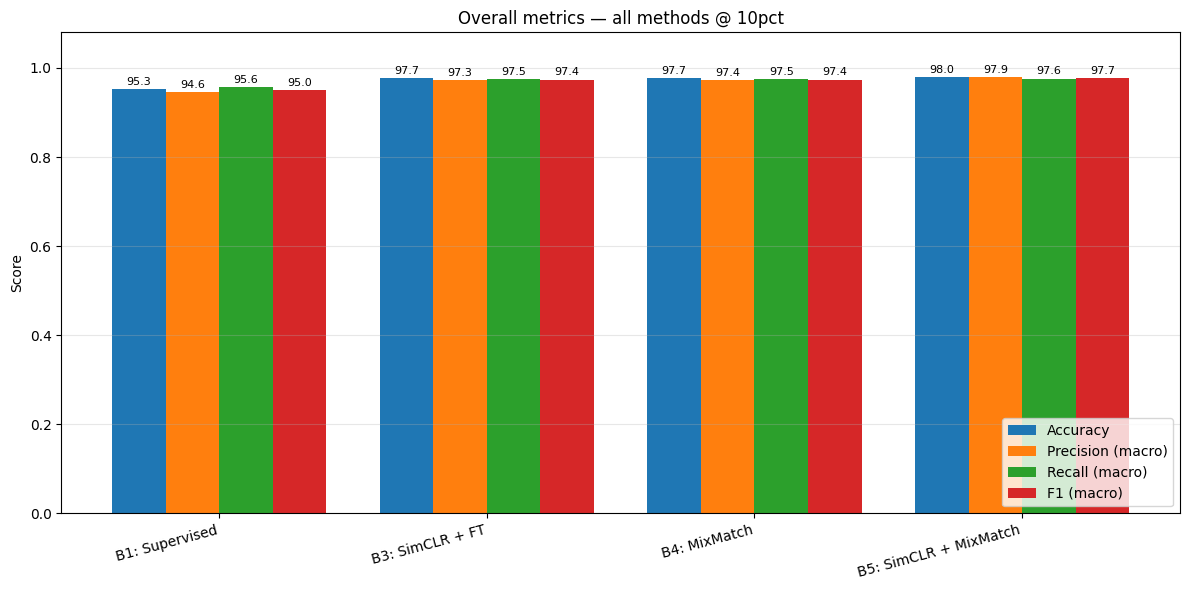

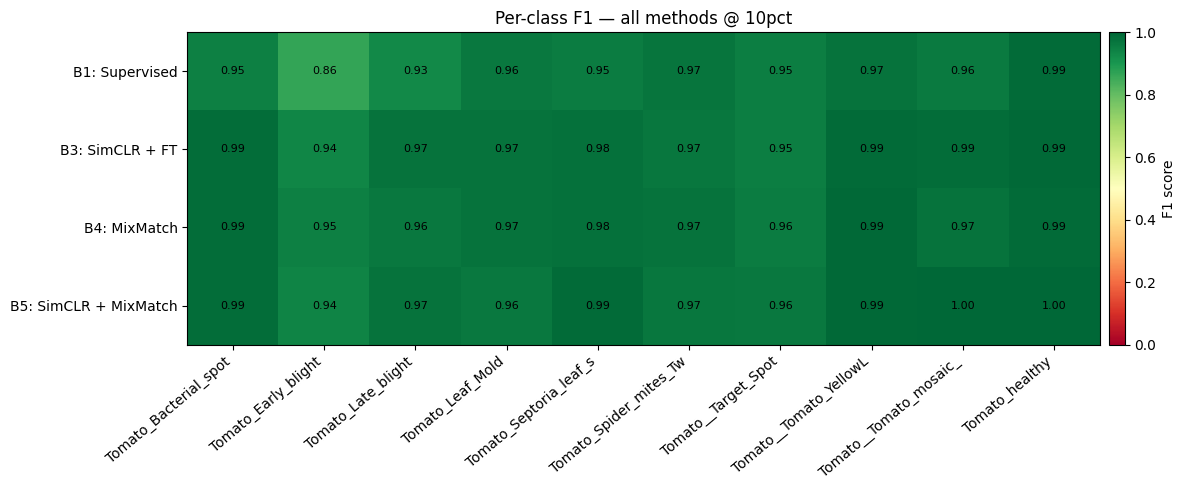

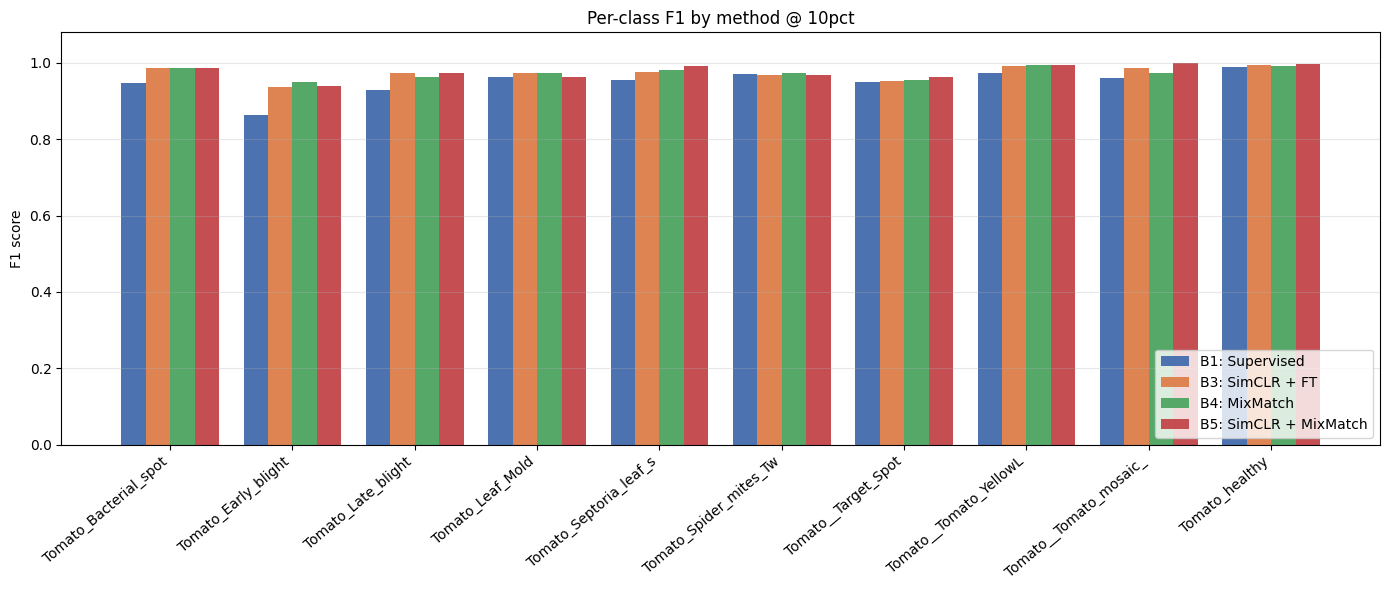


COMPARISON @ 10pct
  Method                         Acc     Prec      Rec       F1    BestVal
  ----------------------------------------------------------------------
  B1: Supervised              95.30%   94.60%   95.65%   94.99%     95.30%
  B3: SimCLR + FT             97.68%   97.33%   97.50%   97.40%     97.68%
  B4: MixMatch                97.75%   97.36%   97.49%   97.40%     97.75%
  B5: SimCLR + MixMatch       98.00%   97.93%   97.60%   97.75%     98.00%

Comparison figures and CSV saved to: /content/drive/MyDrive/Tomato_3regime/RESULTS/10pct/_comparison


In [ ]:
# ===== Section 13.5: Compare all 4 models at current pct_tag =====
import json
import numpy as np
import matplotlib.pyplot as plt

METHOD_ORDER = ["B1_supervised", "B3_self_supervised", "B4_semi_supervised", "B5_hybrid"]
METHOD_DISPLAY = {
    "B1_supervised":      "B1: Supervised",
    "B3_self_supervised": "B3: SimCLR + FT",
    "B4_semi_supervised": "B4: MixMatch",
    "B5_hybrid":          "B5: SimCLR + MixMatch",
}

# Load all 4 metrics.json files for the current pct
all_metrics = {}
for method in METHOD_ORDER:
    path = f"{CUR_OUT}/{method}/metrics.json"
    if os.path.exists(path):
        with open(path) as f:
            all_metrics[method] = json.load(f)
    else:
        print(f"WARNING: {path} not found — did the method finish training?")

if len(all_metrics) < 4:
    print(f"Only {len(all_metrics)}/4 methods have metrics. Run remaining methods first.")
else:
    class_names = base_dataset.classes
    n_classes  = len(class_names)
    n_methods  = len(METHOD_ORDER)
    save_dir   = f"{CUR_OUT}/_comparison"
    os.makedirs(save_dir, exist_ok=True)

    # ===== Figure 1: Overall metrics comparison (grouped bars) =====
    metric_keys = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
    metric_labels = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(n_methods)
    w = 0.2
    for j, (mk, ml) in enumerate(zip(metric_keys, metric_labels)):
        vals = [all_metrics[m]["overall"][mk] for m in METHOD_ORDER]
        bars = ax.bar(x + (j - 1.5) * w, vals, w, label=ml)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.005,
                    f"{v*100:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_DISPLAY[m] for m in METHOD_ORDER], rotation=15, ha="right")
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score")
    ax.set_title(f"Overall metrics — all methods @ {pct_tag}")
    ax.legend(loc="lower right")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/overall_metrics_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ===== Figure 2: Per-class F1 heatmap (4 methods × 10 classes) =====
    f1_matrix = np.zeros((n_methods, n_classes))
    for i, m in enumerate(METHOD_ORDER):
        f1_matrix[i] = all_metrics[m]["per_class"]["f1"]

    fig, ax = plt.subplots(figsize=(max(12, n_classes * 1.1), 5))
    im = ax.imshow(f1_matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(n_classes))
    ax.set_xticklabels([c[:22] for c in class_names], rotation=40, ha="right")
    ax.set_yticks(range(n_methods))
    ax.set_yticklabels([METHOD_DISPLAY[m] for m in METHOD_ORDER])
    for i in range(n_methods):
        for j in range(n_classes):
            v = f1_matrix[i, j]
            color = "white" if v < 0.5 else "black"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color=color, fontsize=8)
    ax.set_title(f"Per-class F1 — all methods @ {pct_tag}")
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, label="F1 score")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/per_class_f1_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ===== Figure 3: Per-class metric bars, grouped by class =====
    # For each class, show 4 bars (one per method) of F1 — easiest to read for the paper
    fig, ax = plt.subplots(figsize=(max(14, n_classes * 1.4), 6))
    x = np.arange(n_classes)
    w = 0.2
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
    for i, m in enumerate(METHOD_ORDER):
        vals = all_metrics[m]["per_class"]["f1"]
        ax.bar(x + (i - 1.5) * w, vals, w,
               label=METHOD_DISPLAY[m], color=colors[i])
    ax.set_xticks(x)
    ax.set_xticklabels([c[:22] for c in class_names], rotation=40, ha="right")
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("F1 score")
    ax.set_title(f"Per-class F1 by method @ {pct_tag}")
    ax.legend(loc="lower right")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/per_class_f1_by_method.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ===== Comparison table (text) =====
    print("\n" + "=" * 80)
    print(f"COMPARISON @ {pct_tag}")
    print("=" * 80)
    print(f"  {'Method':<25} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'BestVal':>10}")
    print("  " + "-" * 70)
    rows = []
    for m in METHOD_ORDER:
        o = all_metrics[m]["overall"]
        bv = all_metrics[m].get("best_val_acc", 0)
        rows.append([METHOD_DISPLAY[m],
                     o["accuracy"]*100, o["precision_macro"]*100,
                     o["recall_macro"]*100, o["f1_macro"]*100, bv])
        print(f"  {METHOD_DISPLAY[m]:<25} {o['accuracy']*100:>7.2f}% "
              f"{o['precision_macro']*100:>7.2f}% {o['recall_macro']*100:>7.2f}% "
              f"{o['f1_macro']*100:>7.2f}% {bv:>9.2f}%")

    # Save comparison table as CSV for the paper
    import csv
    with open(f"{save_dir}/comparison_table.csv", "w", newline="") as f:
        w_csv = csv.writer(f)
        w_csv.writerow(["Method", "Accuracy", "Precision_macro", "Recall_macro",
                        "F1_macro", "Best_val_acc"])
        for r in rows:
            w_csv.writerow([r[0]] + [f"{x:.4f}" for x in r[1:]])

    print(f"\nComparison figures and CSV saved to: {save_dir}")

# Section 9b — Configure Current Label % and Build Loaders
This cell is the one you re-run between experiments. Set to 0.30 now

In [ ]:
LABEL_PCT = 0.30
# ============================================================

pct_tag = f"{int(LABEL_PCT*100)}pct"
CUR_OUT = f"{RESULTS_DIR}/{pct_tag}"
print(f"Active experiment: LABEL_PCT={LABEL_PCT}  (tag: {pct_tag})")
print(f"Output base:       {CUR_OUT}")

set_seed(SEED)
labeled_idx, unlabeled_idx, val_idx = stratified_split_with_floor(
    base_dataset, label_pct=LABEL_PCT, val_pct=VAL_PCT,
    min_per_class=10, seed=SEED,
)

total_n = len(base_dataset)
print(f"\nSplit sizes (target label_pct={LABEL_PCT}, val_pct={VAL_PCT}, floor=10):")
print(f"  Labeled:    {len(labeled_idx):>5} ({100*len(labeled_idx)/total_n:.2f}%)")
print(f"  Unlabeled:  {len(unlabeled_idx):>5} ({100*len(unlabeled_idx)/total_n:.2f}%)")
print(f"  Validation: {len(val_idx):>5} ({100*len(val_idx)/total_n:.2f}%)")

with open(f"{RESULTS_DIR}/splits/split_{pct_tag}_seed{SEED}.json", "w") as f:
    json.dump({
        "seed": SEED, "label_pct": LABEL_PCT, "val_pct": VAL_PCT,
        "min_per_class": 10,
        "labeled_idx": labeled_idx,
        "unlabeled_idx": unlabeled_idx,
        "val_idx": val_idx,
        "classes": base_dataset.classes,
    }, f)

labeled_dataset   = LabeledSubset(base_dataset, labeled_idx,   weak_transform)
unlabeled_dataset = UnlabeledKAug(base_dataset, unlabeled_idx, weak_transform, K=K_AUGMENTS)
val_dataset       = LabeledSubset(base_dataset, val_idx,       eval_transform)

labeled_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
train_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

print(f"\nLoader batch counts:")
print(f"  labeled_loader:   {len(labeled_loader)}")
print(f"  unlabeled_loader: {len(unlabeled_loader)}")
print(f"  val_loader:       {len(val_loader)}")
print(f"  train_loader:     {len(train_loader)}")

results_cur = {}

Active experiment: LABEL_PCT=0.3  (tag: 30pct)
Output base:       /content/drive/MyDrive/Tomato_3regime/RESULTS/30pct

Split sizes (target label_pct=0.3, val_pct=0.1, floor=10):
  Labeled:     4799 (29.97%)
  Unlabeled:   9615 (60.05%)
  Validation:  1597 (9.97%)

Loader batch counts:
  labeled_loader:   37
  unlabeled_loader: 75
  val_loader:       13
  train_loader:     38


#Section 10b — B1: Supervised Baseline (ImageNet Init)

In [ ]:
# ===== B1: Supervised (ImageNet init) =====
set_seed(SEED)

sup_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
sup_model.fc = nn.Linear(512, NUM_CLASSES)
sup_model = sup_model.to(device)

LR_SUP = 1e-3
optimizer = torch.optim.Adam(sup_model.parameters(), lr=LR_SUP)
criterion = nn.CrossEntropyLoss()
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B1 @ {pct_tag}: Supervised (ImageNet init)")
print(f"Epochs: {EPOCHS}  LR: {LR_SUP}  Batch: {BATCH_SIZE}")
print("=" * 64)

b1_history = {"epoch": [], "train_loss": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    sup_model.train()
    tl, nb = 0.0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = criterion(sup_model(imgs), labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tl += loss.item(); nb += 1

    sup_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (sup_model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b1_history["epoch"].append(epoch + 1)
    b1_history["train_loss"].append(tl / nb)
    b1_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(sup_model.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  loss={tl/nb:.4f}  val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB1 done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

sup_model.load_state_dict(best_state)
results_cur["B1_supervised"] = best

metrics_b1 = full_evaluation(
    model=sup_model, loader=val_loader,
    class_names=base_dataset.classes, method_name="B1_supervised",
    history=b1_history,
    out_dir=f"{CUR_OUT}/B1_supervised",
    pct_tag=pct_tag,
)

del sup_model, optimizer
empty_cache()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 231MB/s]

B1 @ 30pct: Supervised (ImageNet init)
Epochs: 30  LR: 0.001  Batch: 128


  Ep  1/30  loss=0.3842  val=76.96%  (best: 76.96%)
  Ep  2/30  loss=0.1363  val=82.47%  (best: 82.47%)
  Ep  3/30  loss=0.1306  val=95.18%  (best: 95.18%)
  Ep  4/30  loss=0.0912  val=86.98%  (best: 95.18%)
  Ep  5/30  loss=0.0732  val=96.12%  (best: 96.12%)
  Ep  6/30  loss=0.0455  val=91.30%  (best: 96.12%)
  Ep  7/30  loss=0.0835  val=89.10%  (best: 96.12%)
  Ep  8/30  loss=0.0878  val=88.42%  (best: 96.12%)
  Ep  9/30  loss=0.0532  val=95.62%  (best: 96.12%)
  Ep 10/30  loss=0.0278  val=96.99%  (best: 96.99%)
  Ep 11/30  loss=0.0253  val=96.87%  (best: 96.99%)
  Ep 12/30  loss=0.0247  val=98.18%  (best: 98.18%)
  Ep 13/30  loss=0.0339  val=93.80%  (best: 98.18%)
  Ep 14/30  loss=0.0427  val=95.99%  (best: 98.18%)
  Ep 15/30  loss=0.0290  val=97.62%  (best: 98.18%)
  Ep 16/30  loss=0.0133  val=98.25%  (best: 98.25%)
  Ep 17/30  loss=0.0182  val=98.37%  (best: 98.37%)
  Ep 18/30  loss=0.0177  val=95.55%  (best: 98.37%)
  Ep 19/30  loss=0.0282  val=93.17%  (best: 98.37%)
  Ep 20/30  

#Section 11b — B3: Self-Supervised (SimCLR + Full Fine-tune)

In [ ]:
# ===== B3: Self-supervised (SimCLR + Full Fine-tune) =====
class SimCLRFineTune(nn.Module):
    def __init__(self, pretrained_encoder, num_classes):
        super().__init__()
        self.encoder = copy.deepcopy(pretrained_encoder)
        self.classifier = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.classifier(self.encoder(x))


set_seed(SEED)
simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])

ft_model = SimCLRFineTune(simclr_clean.encoder, NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(ft_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B3 @ {pct_tag}: SimCLR + Full Fine-tune (LR=1e-4)")
print("=" * 64)

b3_history = {"epoch": [], "train_loss": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    ft_model.train()
    tl, nb = 0.0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = criterion(ft_model(imgs), labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tl += loss.item(); nb += 1

    ft_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (ft_model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b3_history["epoch"].append(epoch + 1)
    b3_history["train_loss"].append(tl / nb)
    b3_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(ft_model.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  loss={tl/nb:.3f}  val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB3 done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

ft_model.load_state_dict(best_state)
results_cur["B3_self_supervised"] = best

metrics_b3 = full_evaluation(
    model=ft_model, loader=val_loader,
    class_names=base_dataset.classes, method_name="B3_self_supervised",
    history=b3_history,
    out_dir=f"{CUR_OUT}/B3_self_supervised",
    pct_tag=pct_tag,
)

del ft_model, optimizer, simclr_clean
empty_cache()

B3 @ 30pct: SimCLR + Full Fine-tune (LR=1e-4)
  Ep  1/30  loss=0.728  val=91.23%  (best: 91.23%)
  Ep  2/30  loss=0.158  val=97.24%  (best: 97.24%)
  Ep  3/30  loss=0.075  val=97.18%  (best: 97.24%)
  Ep  4/30  loss=0.045  val=97.81%  (best: 97.81%)
  Ep  5/30  loss=0.028  val=98.50%  (best: 98.50%)
  Ep  6/30  loss=0.017  val=99.12%  (best: 99.12%)
  Ep  7/30  loss=0.016  val=99.19%  (best: 99.19%)
  Ep  8/30  loss=0.014  val=98.50%  (best: 99.19%)
  Ep  9/30  loss=0.012  val=98.43%  (best: 99.19%)
  Ep 10/30  loss=0.007  val=99.19%  (best: 99.19%)
  Ep 11/30  loss=0.006  val=98.94%  (best: 99.19%)
  Ep 12/30  loss=0.006  val=99.37%  (best: 99.37%)
  Ep 13/30  loss=0.004  val=99.06%  (best: 99.37%)
  Ep 14/30  loss=0.003  val=99.31%  (best: 99.37%)
  Ep 15/30  loss=0.004  val=99.12%  (best: 99.37%)
  Ep 16/30  loss=0.003  val=98.50%  (best: 99.37%)
  Ep 17/30  loss=0.003  val=99.25%  (best: 99.37%)
  Ep 18/30  loss=0.002  val=99.31%  (best: 99.37%)
  Ep 19/30  loss=0.002  val=99.19%  

#Section 12b — B4: Semi-Supervised (MixMatch, ImageNet Init)


In [ ]:
# ===== B4: Semi-supervised MixMatch (ImageNet init) =====
set_seed(SEED)

mm_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
mm_model.fc = nn.Linear(512, NUM_CLASSES)
mm_model = mm_model.to(device)

LR_MM = 1e-4
optimizer = torch.optim.Adam(mm_model.parameters(), lr=LR_MM)
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B4 @ {pct_tag}: MixMatch (ImageNet init)")
print(f"Epochs: {EPOCHS}  LR: {LR_MM}  K: {K_AUGMENTS}  λu: {LAMBDA_U}")
print("=" * 64)

b4_history = {"epoch": [], "loss_x": [], "loss_u": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    mm_model.train()
    tlx, tlu, nb = 0.0, 0.0, 0
    uiter = iter(unlabeled_loader)
    for bx, by in labeled_loader:
        try: buv = next(uiter)
        except StopIteration:
            uiter = iter(unlabeled_loader); buv = next(uiter)
        bx, by = bx.to(device), by.to(device)
        buv = [v.to(device) for v in buv]

        with torch.no_grad():
            probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
            for v in buv:
                probs += F.softmax(mm_model(v), dim=1)
            probs /= len(buv)
            pseudo = sharpen(probs, T=SHARPEN_TEMP)

        loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
        ai = torch.cat([bx] + buv, dim=0)
        at = torch.cat([loh] + [pseudo] * len(buv), dim=0)
        si = torch.randperm(ai.size(0))
        mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)

        n = bx.size(0)
        xp, yp = mx[:n], my[:n]
        up, uy = mx[n:], my[n:]

        lx = -torch.mean(torch.sum(yp * F.log_softmax(mm_model(xp), dim=1), dim=1))
        lu = F.mse_loss(F.softmax(mm_model(up), dim=1), uy)
        loss = lx + LAMBDA_U * lu

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tlx += lx.item(); tlu += lu.item(); nb += 1

    mm_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (mm_model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b4_history["epoch"].append(epoch + 1)
    b4_history["loss_x"].append(tlx / nb)
    b4_history["loss_u"].append(tlu / nb)
    b4_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(mm_model.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  lx={tlx/nb:.3f}  lu={tlu/nb:.4f}  "
          f"val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB4 done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

mm_model.load_state_dict(best_state)
results_cur["B4_semi_supervised"] = best

metrics_b4 = full_evaluation(
    model=mm_model, loader=val_loader,
    class_names=base_dataset.classes, method_name="B4_semi_supervised",
    history=b4_history,
    out_dir=f"{CUR_OUT}/B4_semi_supervised",
    pct_tag=pct_tag,
)

del mm_model, optimizer
empty_cache()

B4 @ 30pct: MixMatch (ImageNet init)
Epochs: 30  LR: 0.0001  K: 2  λu: 1.0
  Ep  1/30  lx=1.275  lu=0.0077  val=94.24%  (best: 94.24%)
  Ep  2/30  lx=0.858  lu=0.0068  val=96.56%  (best: 96.56%)
  Ep  3/30  lx=0.885  lu=0.0082  val=97.56%  (best: 97.56%)
  Ep  4/30  lx=0.668  lu=0.0054  val=97.68%  (best: 97.68%)
  Ep  5/30  lx=0.828  lu=0.0078  val=98.12%  (best: 98.12%)
  Ep  6/30  lx=0.797  lu=0.0067  val=98.43%  (best: 98.43%)
  Ep  7/30  lx=0.753  lu=0.0063  val=98.43%  (best: 98.43%)
  Ep  8/30  lx=0.729  lu=0.0068  val=98.69%  (best: 98.69%)
  Ep  9/30  lx=0.677  lu=0.0055  val=98.56%  (best: 98.69%)
  Ep 10/30  lx=0.736  lu=0.0065  val=99.25%  (best: 99.25%)
  Ep 11/30  lx=0.654  lu=0.0055  val=99.00%  (best: 99.25%)
  Ep 12/30  lx=0.747  lu=0.0063  val=99.37%  (best: 99.37%)
  Ep 13/30  lx=0.696  lu=0.0066  val=99.44%  (best: 99.44%)
  Ep 14/30  lx=0.745  lu=0.0064  val=99.37%  (best: 99.44%)
  Ep 15/30  lx=0.671  lu=0.0053  val=99.31%  (best: 99.44%)
  Ep 16/30  lx=0.658  lu=

#Section 13b — B5-full: Hybrid (SimCLR + MixMatch Full FT)

In [ ]:
# ===== B5 (full): Hybrid — SimCLR + MixMatch full FT =====
class SimCLRMixMatchFull(nn.Module):
    def __init__(self, pretrained_encoder, num_classes):
        super().__init__()
        self.encoder = copy.deepcopy(pretrained_encoder)
        self.classifier = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.classifier(self.encoder(x))


set_seed(SEED)
simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])

b5_full = SimCLRMixMatchFull(simclr_clean.encoder, NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(b5_full.parameters(), lr=1e-4)
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B5-full @ {pct_tag}: SimCLR + MixMatch full FT (LR=1e-4)")
print(f"Epochs: {EPOCHS}  K: {K_AUGMENTS}  λu: {LAMBDA_U}")
print("=" * 64)

b5_history = {"epoch": [], "loss_x": [], "loss_u": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    b5_full.train()
    tlx, tlu, nb = 0.0, 0.0, 0
    uiter = iter(unlabeled_loader)
    for bx, by in labeled_loader:
        try: buv = next(uiter)
        except StopIteration:
            uiter = iter(unlabeled_loader); buv = next(uiter)
        bx, by = bx.to(device), by.to(device)
        buv = [v.to(device) for v in buv]

        with torch.no_grad():
            probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
            for v in buv:
                probs += F.softmax(b5_full(v), dim=1)
            probs /= len(buv)
            pseudo = sharpen(probs, T=SHARPEN_TEMP)

        loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
        ai = torch.cat([bx] + buv, dim=0)
        at = torch.cat([loh] + [pseudo] * len(buv), dim=0)
        si = torch.randperm(ai.size(0))
        mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)

        n = bx.size(0)
        xp, yp = mx[:n], my[:n]
        up, uy = mx[n:], my[n:]

        lx = -torch.mean(torch.sum(yp * F.log_softmax(b5_full(xp), dim=1), dim=1))
        lu = F.mse_loss(F.softmax(b5_full(up), dim=1), uy)
        loss = lx + LAMBDA_U * lu

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tlx += lx.item(); tlu += lu.item(); nb += 1

    b5_full.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (b5_full(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b5_history["epoch"].append(epoch + 1)
    b5_history["loss_x"].append(tlx / nb)
    b5_history["loss_u"].append(tlu / nb)
    b5_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(b5_full.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  lx={tlx/nb:.3f}  lu={tlu/nb:.4f}  "
          f"val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB5-full done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

b5_full.load_state_dict(best_state)
results_cur["B5_hybrid"] = best

metrics_b5 = full_evaluation(
    model=b5_full, loader=val_loader,
    class_names=base_dataset.classes, method_name="B5_hybrid",
    history=b5_history,
    out_dir=f"{CUR_OUT}/B5_hybrid",
    pct_tag=pct_tag,
)

del b5_full, optimizer, simclr_clean
empty_cache()

# Print summary for this percentage
print("\n" + "=" * 64)
print(f"SUMMARY @ {pct_tag}")
print("=" * 64)
for method, acc in results_cur.items():
    print(f"  {method:<25}  {acc:.2f}%")

B5-full @ 30pct: SimCLR + MixMatch full FT (LR=1e-4)
Epochs: 30  K: 2  λu: 1.0
  Ep  1/30  lx=1.290  lu=0.0077  val=91.61%  (best: 91.61%)
  Ep  2/30  lx=0.899  lu=0.0068  val=96.31%  (best: 96.31%)
  Ep  3/30  lx=0.909  lu=0.0087  val=96.06%  (best: 96.31%)
  Ep  4/30  lx=0.678  lu=0.0055  val=98.37%  (best: 98.37%)
  Ep  5/30  lx=0.841  lu=0.0076  val=98.12%  (best: 98.37%)
  Ep  6/30  lx=0.802  lu=0.0067  val=98.50%  (best: 98.50%)
  Ep  7/30  lx=0.753  lu=0.0064  val=98.50%  (best: 98.50%)
  Ep  8/30  lx=0.743  lu=0.0068  val=98.69%  (best: 98.69%)
  Ep  9/30  lx=0.690  lu=0.0055  val=99.06%  (best: 99.06%)
  Ep 10/30  lx=0.743  lu=0.0064  val=98.87%  (best: 99.06%)
  Ep 11/30  lx=0.648  lu=0.0054  val=99.56%  (best: 99.56%)
  Ep 12/30  lx=0.750  lu=0.0063  val=99.31%  (best: 99.56%)
  Ep 13/30  lx=0.692  lu=0.0064  val=99.25%  (best: 99.56%)
  Ep 14/30  lx=0.742  lu=0.0063  val=99.25%  (best: 99.56%)
  Ep 15/30  lx=0.667  lu=0.0052  val=99.44%  (best: 99.56%)
  Ep 16/30  lx=0.663 

#Section 13.5b — Within-percentage comparison

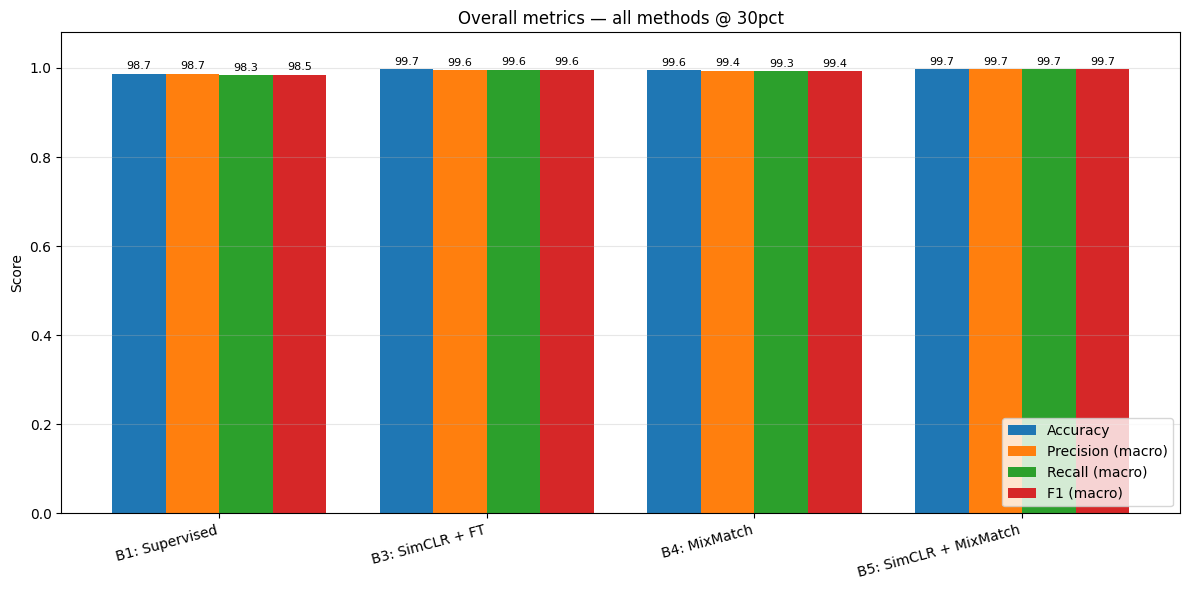

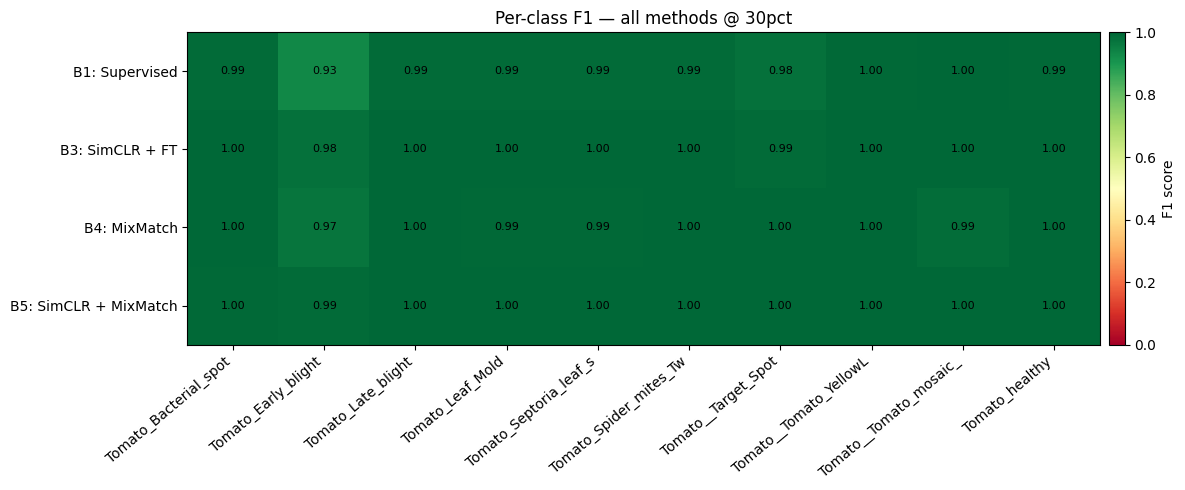

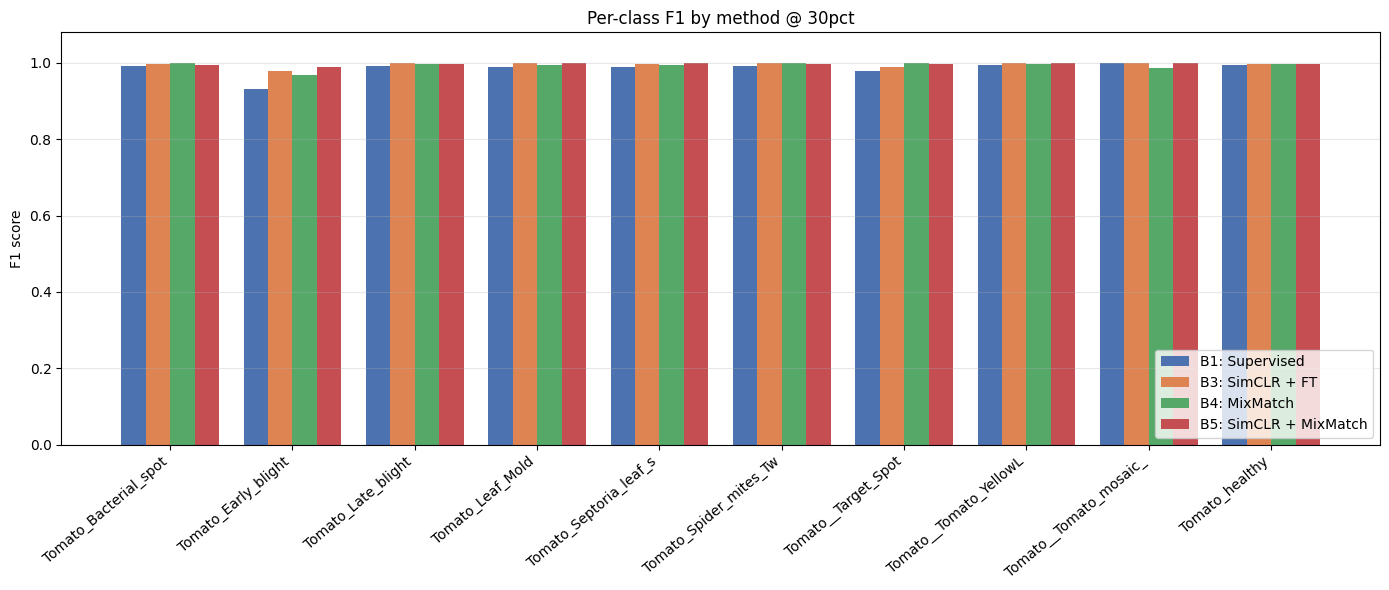


COMPARISON @ 30pct
  Method                         Acc     Prec      Rec       F1    BestVal
  ----------------------------------------------------------------------
  B1: Supervised              98.75%   98.74%   98.34%   98.52%     98.75%
  B3: SimCLR + FT             99.69%   99.60%   99.62%   99.61%     99.69%
  B4: MixMatch                99.56%   99.41%   99.33%   99.36%     99.56%
  B5: SimCLR + MixMatch       99.75%   99.72%   99.74%   99.73%     99.75%

Comparison figures and CSV saved to: /content/drive/MyDrive/Tomato_3regime/RESULTS/30pct/_comparison


In [ ]:
# ===== Section 13.5: Compare all 4 models at current pct_tag =====
import json
import numpy as np
import matplotlib.pyplot as plt

METHOD_ORDER = ["B1_supervised", "B3_self_supervised", "B4_semi_supervised", "B5_hybrid"]
METHOD_DISPLAY = {
    "B1_supervised":      "B1: Supervised",
    "B3_self_supervised": "B3: SimCLR + FT",
    "B4_semi_supervised": "B4: MixMatch",
    "B5_hybrid":          "B5: SimCLR + MixMatch",
}

# Load all 4 metrics.json files for the current pct
all_metrics = {}
for method in METHOD_ORDER:
    path = f"{CUR_OUT}/{method}/metrics.json"
    if os.path.exists(path):
        with open(path) as f:
            all_metrics[method] = json.load(f)
    else:
        print(f"WARNING: {path} not found — did the method finish training?")

if len(all_metrics) < 4:
    print(f"Only {len(all_metrics)}/4 methods have metrics. Run remaining methods first.")
else:
    class_names = base_dataset.classes
    n_classes  = len(class_names)
    n_methods  = len(METHOD_ORDER)
    save_dir   = f"{CUR_OUT}/_comparison"
    os.makedirs(save_dir, exist_ok=True)

    # ===== Figure 1: Overall metrics comparison (grouped bars) =====
    metric_keys = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
    metric_labels = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(n_methods)
    w = 0.2
    for j, (mk, ml) in enumerate(zip(metric_keys, metric_labels)):
        vals = [all_metrics[m]["overall"][mk] for m in METHOD_ORDER]
        bars = ax.bar(x + (j - 1.5) * w, vals, w, label=ml)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.005,
                    f"{v*100:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_DISPLAY[m] for m in METHOD_ORDER], rotation=15, ha="right")
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score")
    ax.set_title(f"Overall metrics — all methods @ {pct_tag}")
    ax.legend(loc="lower right")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/overall_metrics_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ===== Figure 2: Per-class F1 heatmap (4 methods × 10 classes) =====
    f1_matrix = np.zeros((n_methods, n_classes))
    for i, m in enumerate(METHOD_ORDER):
        f1_matrix[i] = all_metrics[m]["per_class"]["f1"]

    fig, ax = plt.subplots(figsize=(max(12, n_classes * 1.1), 5))
    im = ax.imshow(f1_matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(n_classes))
    ax.set_xticklabels([c[:22] for c in class_names], rotation=40, ha="right")
    ax.set_yticks(range(n_methods))
    ax.set_yticklabels([METHOD_DISPLAY[m] for m in METHOD_ORDER])
    for i in range(n_methods):
        for j in range(n_classes):
            v = f1_matrix[i, j]
            color = "white" if v < 0.5 else "black"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color=color, fontsize=8)
    ax.set_title(f"Per-class F1 — all methods @ {pct_tag}")
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, label="F1 score")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/per_class_f1_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ===== Figure 3: Per-class metric bars, grouped by class =====
    # For each class, show 4 bars (one per method) of F1 — easiest to read for the paper
    fig, ax = plt.subplots(figsize=(max(14, n_classes * 1.4), 6))
    x = np.arange(n_classes)
    w = 0.2
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
    for i, m in enumerate(METHOD_ORDER):
        vals = all_metrics[m]["per_class"]["f1"]
        ax.bar(x + (i - 1.5) * w, vals, w,
               label=METHOD_DISPLAY[m], color=colors[i])
    ax.set_xticks(x)
    ax.set_xticklabels([c[:22] for c in class_names], rotation=40, ha="right")
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("F1 score")
    ax.set_title(f"Per-class F1 by method @ {pct_tag}")
    ax.legend(loc="lower right")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/per_class_f1_by_method.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ===== Comparison table (text) =====
    print("\n" + "=" * 80)
    print(f"COMPARISON @ {pct_tag}")
    print("=" * 80)
    print(f"  {'Method':<25} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'BestVal':>10}")
    print("  " + "-" * 70)
    rows = []
    for m in METHOD_ORDER:
        o = all_metrics[m]["overall"]
        bv = all_metrics[m].get("best_val_acc", 0)
        rows.append([METHOD_DISPLAY[m],
                     o["accuracy"]*100, o["precision_macro"]*100,
                     o["recall_macro"]*100, o["f1_macro"]*100, bv])
        print(f"  {METHOD_DISPLAY[m]:<25} {o['accuracy']*100:>7.2f}% "
              f"{o['precision_macro']*100:>7.2f}% {o['recall_macro']*100:>7.2f}% "
              f"{o['f1_macro']*100:>7.2f}% {bv:>9.2f}%")

    # Save comparison table as CSV for the paper
    import csv
    with open(f"{save_dir}/comparison_table.csv", "w", newline="") as f:
        w_csv = csv.writer(f)
        w_csv.writerow(["Method", "Accuracy", "Precision_macro", "Recall_macro",
                        "F1_macro", "Best_val_acc"])
        for r in rows:
            w_csv.writerow([r[0]] + [f"{x:.4f}" for x in r[1:]])

    print(f"\nComparison figures and CSV saved to: {save_dir}")

# Section 9c — Configure Current Label % and Build Loaders
This cell is the one you re-run between experiments. Set to 0.30 now

In [16]:
LABEL_PCT = 0.50
# ============================================================

pct_tag = f"{int(LABEL_PCT*100)}pct"
CUR_OUT = f"{RESULTS_DIR}/{pct_tag}"
print(f"Active experiment: LABEL_PCT={LABEL_PCT}  (tag: {pct_tag})")
print(f"Output base:       {CUR_OUT}")

set_seed(SEED)
labeled_idx, unlabeled_idx, val_idx = stratified_split_with_floor(
    base_dataset, label_pct=LABEL_PCT, val_pct=VAL_PCT,
    min_per_class=10, seed=SEED,
)

total_n = len(base_dataset)
print(f"\nSplit sizes (target label_pct={LABEL_PCT}, val_pct={VAL_PCT}, floor=10):")
print(f"  Labeled:    {len(labeled_idx):>5} ({100*len(labeled_idx)/total_n:.2f}%)")
print(f"  Unlabeled:  {len(unlabeled_idx):>5} ({100*len(unlabeled_idx)/total_n:.2f}%)")
print(f"  Validation: {len(val_idx):>5} ({100*len(val_idx)/total_n:.2f}%)")

with open(f"{RESULTS_DIR}/splits/split_{pct_tag}_seed{SEED}.json", "w") as f:
    json.dump({
        "seed": SEED, "label_pct": LABEL_PCT, "val_pct": VAL_PCT,
        "min_per_class": 10,
        "labeled_idx": labeled_idx,
        "unlabeled_idx": unlabeled_idx,
        "val_idx": val_idx,
        "classes": base_dataset.classes,
    }, f)

labeled_dataset   = LabeledSubset(base_dataset, labeled_idx,   weak_transform)
unlabeled_dataset = UnlabeledKAug(base_dataset, unlabeled_idx, weak_transform, K=K_AUGMENTS)
val_dataset       = LabeledSubset(base_dataset, val_idx,       eval_transform)

labeled_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
train_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

print(f"\nLoader batch counts:")
print(f"  labeled_loader:   {len(labeled_loader)}")
print(f"  unlabeled_loader: {len(unlabeled_loader)}")
print(f"  val_loader:       {len(val_loader)}")
print(f"  train_loader:     {len(train_loader)}")

results_cur = {}

Active experiment: LABEL_PCT=0.5  (tag: 50pct)
Output base:       /content/drive/MyDrive/Tomato_3regime/RESULTS/50pct

Split sizes (target label_pct=0.5, val_pct=0.1, floor=10):
  Labeled:     8003 (49.98%)
  Unlabeled:   6411 (40.04%)
  Validation:  1597 (9.97%)

Loader batch counts:
  labeled_loader:   62
  unlabeled_loader: 50
  val_loader:       13
  train_loader:     63


#Section 10c — B1: Supervised Baseline (ImageNet Init)

In [14]:
# ===== B1: Supervised (ImageNet init) =====
set_seed(SEED)

sup_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
sup_model.fc = nn.Linear(512, NUM_CLASSES)
sup_model = sup_model.to(device)

LR_SUP = 1e-3
optimizer = torch.optim.Adam(sup_model.parameters(), lr=LR_SUP)
criterion = nn.CrossEntropyLoss()
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B1 @ {pct_tag}: Supervised (ImageNet init)")
print(f"Epochs: {EPOCHS}  LR: {LR_SUP}  Batch: {BATCH_SIZE}")
print("=" * 64)

b1_history = {"epoch": [], "train_loss": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    sup_model.train()
    tl, nb = 0.0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = criterion(sup_model(imgs), labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tl += loss.item(); nb += 1

    sup_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (sup_model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b1_history["epoch"].append(epoch + 1)
    b1_history["train_loss"].append(tl / nb)
    b1_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(sup_model.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  loss={tl/nb:.4f}  val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB1 done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

sup_model.load_state_dict(best_state)
results_cur["B1_supervised"] = best

metrics_b1 = full_evaluation(
    model=sup_model, loader=val_loader,
    class_names=base_dataset.classes, method_name="B1_supervised",
    history=b1_history,
    out_dir=f"{CUR_OUT}/B1_supervised",
    pct_tag=pct_tag,
)

del sup_model, optimizer
empty_cache()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


B1 @ 50pct: Supervised (ImageNet init)
Epochs: 30  LR: 0.001  Batch: 128
  Ep  1/30  loss=0.2940  val=79.71%  (best: 79.71%)
  Ep  2/30  loss=0.1008  val=91.42%  (best: 91.42%)
  Ep  3/30  loss=0.0838  val=92.24%  (best: 92.24%)
  Ep  4/30  loss=0.0714  val=94.36%  (best: 94.36%)
  Ep  5/30  loss=0.0674  val=95.24%  (best: 95.24%)
  Ep  6/30  loss=0.0621  val=95.62%  (best: 95.62%)
  Ep  7/30  loss=0.0573  val=98.25%  (best: 98.25%)
  Ep  8/30  loss=0.0367  val=96.37%  (best: 98.25%)
  Ep  9/30  loss=0.0212  val=98.69%  (best: 98.69%)
  Ep 10/30  loss=0.0229  val=97.06%  (best: 98.69%)
  Ep 11/30  loss=0.0352  val=94.99%  (best: 98.69%)
  Ep 12/30  loss=0.0707  val=85.28%  (best: 98.69%)
  Ep 13/30  loss=0.0500  val=97.31%  (best: 98.69%)
  Ep 14/30  loss=0.0427  val=95.30%  (best: 98.69%)
  Ep 15/30  loss=0.0267  val=96.37%  (best: 98.69%)
  Ep 16/30  loss=0.0130  val=97.37%  (best: 98.69%)
  Ep 17/30  loss=0.0173  val=98.94%  (best: 98.94%)
  Ep 18/30  loss=0.0170  val=98.56%  (best:

#Section 11c — B3: Self-Supervised (SimCLR + Full Fine-tune)

In [15]:
# ===== B3: Self-supervised (SimCLR + Full Fine-tune) =====
class SimCLRFineTune(nn.Module):
    def __init__(self, pretrained_encoder, num_classes):
        super().__init__()
        self.encoder = copy.deepcopy(pretrained_encoder)
        self.classifier = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.classifier(self.encoder(x))


set_seed(SEED)
simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])

ft_model = SimCLRFineTune(simclr_clean.encoder, NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(ft_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B3 @ {pct_tag}: SimCLR + Full Fine-tune (LR=1e-4)")
print("=" * 64)

b3_history = {"epoch": [], "train_loss": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    ft_model.train()
    tl, nb = 0.0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = criterion(ft_model(imgs), labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tl += loss.item(); nb += 1

    ft_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (ft_model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b3_history["epoch"].append(epoch + 1)
    b3_history["train_loss"].append(tl / nb)
    b3_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(ft_model.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  loss={tl/nb:.3f}  val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB3 done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

ft_model.load_state_dict(best_state)
results_cur["B3_self_supervised"] = best

metrics_b3 = full_evaluation(
    model=ft_model, loader=val_loader,
    class_names=base_dataset.classes, method_name="B3_self_supervised",
    history=b3_history,
    out_dir=f"{CUR_OUT}/B3_self_supervised",
    pct_tag=pct_tag,
)

del ft_model, optimizer, simclr_clean
empty_cache()

B3 @ 50pct: SimCLR + Full Fine-tune (LR=1e-4)
  Ep  1/30  loss=0.521  val=95.24%  (best: 95.24%)
  Ep  2/30  loss=0.093  val=97.18%  (best: 97.18%)
  Ep  3/30  loss=0.042  val=97.50%  (best: 97.50%)
  Ep  4/30  loss=0.025  val=98.25%  (best: 98.25%)
  Ep  5/30  loss=0.018  val=98.56%  (best: 98.56%)
  Ep  6/30  loss=0.013  val=98.31%  (best: 98.56%)
  Ep  7/30  loss=0.011  val=98.75%  (best: 98.75%)
  Ep  8/30  loss=0.009  val=98.25%  (best: 98.75%)
  Ep  9/30  loss=0.009  val=98.25%  (best: 98.75%)
  Ep 10/30  loss=0.016  val=98.81%  (best: 98.81%)
  Ep 11/30  loss=0.009  val=98.94%  (best: 98.94%)
  Ep 12/30  loss=0.003  val=98.81%  (best: 98.94%)
  Ep 13/30  loss=0.005  val=98.87%  (best: 98.94%)
  Ep 14/30  loss=0.003  val=98.87%  (best: 98.94%)
  Ep 15/30  loss=0.002  val=99.25%  (best: 99.25%)
  Ep 16/30  loss=0.002  val=99.25%  (best: 99.25%)
  Ep 17/30  loss=0.005  val=98.87%  (best: 99.25%)
  Ep 18/30  loss=0.007  val=98.94%  (best: 99.25%)
  Ep 19/30  loss=0.003  val=99.25%  

#Section 12c — B4: Semi-Supervised (MixMatch, ImageNet Init)


In [16]:
# ===== B4: Semi-supervised MixMatch (ImageNet init) =====
set_seed(SEED)

mm_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
mm_model.fc = nn.Linear(512, NUM_CLASSES)
mm_model = mm_model.to(device)

LR_MM = 1e-4
optimizer = torch.optim.Adam(mm_model.parameters(), lr=LR_MM)
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B4 @ {pct_tag}: MixMatch (ImageNet init)")
print(f"Epochs: {EPOCHS}  LR: {LR_MM}  K: {K_AUGMENTS}  λu: {LAMBDA_U}")
print("=" * 64)

b4_history = {"epoch": [], "loss_x": [], "loss_u": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    mm_model.train()
    tlx, tlu, nb = 0.0, 0.0, 0
    uiter = iter(unlabeled_loader)
    for bx, by in labeled_loader:
        try: buv = next(uiter)
        except StopIteration:
            uiter = iter(unlabeled_loader); buv = next(uiter)
        bx, by = bx.to(device), by.to(device)
        buv = [v.to(device) for v in buv]

        with torch.no_grad():
            probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
            for v in buv:
                probs += F.softmax(mm_model(v), dim=1)
            probs /= len(buv)
            pseudo = sharpen(probs, T=SHARPEN_TEMP)

        loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
        ai = torch.cat([bx] + buv, dim=0)
        at = torch.cat([loh] + [pseudo] * len(buv), dim=0)
        si = torch.randperm(ai.size(0))
        mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)

        n = bx.size(0)
        xp, yp = mx[:n], my[:n]
        up, uy = mx[n:], my[n:]

        lx = -torch.mean(torch.sum(yp * F.log_softmax(mm_model(xp), dim=1), dim=1))
        lu = F.mse_loss(F.softmax(mm_model(up), dim=1), uy)
        loss = lx + LAMBDA_U * lu

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tlx += lx.item(); tlu += lu.item(); nb += 1

    mm_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (mm_model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b4_history["epoch"].append(epoch + 1)
    b4_history["loss_x"].append(tlx / nb)
    b4_history["loss_u"].append(tlu / nb)
    b4_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(mm_model.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  lx={tlx/nb:.3f}  lu={tlu/nb:.4f}  "
          f"val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB4 done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

mm_model.load_state_dict(best_state)
results_cur["B4_semi_supervised"] = best

metrics_b4 = full_evaluation(
    model=mm_model, loader=val_loader,
    class_names=base_dataset.classes, method_name="B4_semi_supervised",
    history=b4_history,
    out_dir=f"{CUR_OUT}/B4_semi_supervised",
    pct_tag=pct_tag,
)

del mm_model, optimizer
empty_cache()

B4 @ 50pct: MixMatch (ImageNet init)
Epochs: 30  LR: 0.0001  K: 2  λu: 1.0
  Ep  1/30  lx=1.135  lu=0.0076  val=96.24%  (best: 96.24%)
  Ep  2/30  lx=0.821  lu=0.0073  val=98.00%  (best: 98.00%)
  Ep  3/30  lx=0.756  lu=0.0064  val=98.06%  (best: 98.06%)
  Ep  4/30  lx=0.798  lu=0.0066  val=98.00%  (best: 98.06%)
  Ep  5/30  lx=0.718  lu=0.0064  val=98.62%  (best: 98.62%)
  Ep  6/30  lx=0.742  lu=0.0063  val=98.69%  (best: 98.69%)
  Ep  7/30  lx=0.679  lu=0.0057  val=98.81%  (best: 98.81%)
  Ep  8/30  lx=0.741  lu=0.0066  val=98.62%  (best: 98.81%)
  Ep  9/30  lx=0.679  lu=0.0055  val=98.87%  (best: 98.87%)
  Ep 10/30  lx=0.664  lu=0.0053  val=98.87%  (best: 98.87%)
  Ep 11/30  lx=0.682  lu=0.0056  val=98.87%  (best: 98.87%)
  Ep 12/30  lx=0.605  lu=0.0045  val=99.12%  (best: 99.12%)
  Ep 13/30  lx=0.641  lu=0.0051  val=99.06%  (best: 99.12%)
  Ep 14/30  lx=0.599  lu=0.0047  val=98.94%  (best: 99.12%)
  Ep 15/30  lx=0.618  lu=0.0047  val=99.00%  (best: 99.12%)
  Ep 16/30  lx=0.589  lu=

#Section 13c — B5-full: Hybrid (SimCLR + MixMatch Full FT)

In [17]:
# ===== B5 (full): Hybrid — SimCLR + MixMatch full FT =====
class SimCLRMixMatchFull(nn.Module):
    def __init__(self, pretrained_encoder, num_classes):
        super().__init__()
        self.encoder = copy.deepcopy(pretrained_encoder)
        self.classifier = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.classifier(self.encoder(x))


set_seed(SEED)
simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])

b5_full = SimCLRMixMatchFull(simclr_clean.encoder, NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(b5_full.parameters(), lr=1e-4)
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B5-full @ {pct_tag}: SimCLR + MixMatch full FT (LR=1e-4)")
print(f"Epochs: {EPOCHS}  K: {K_AUGMENTS}  λu: {LAMBDA_U}")
print("=" * 64)

b5_history = {"epoch": [], "loss_x": [], "loss_u": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    b5_full.train()
    tlx, tlu, nb = 0.0, 0.0, 0
    uiter = iter(unlabeled_loader)
    for bx, by in labeled_loader:
        try: buv = next(uiter)
        except StopIteration:
            uiter = iter(unlabeled_loader); buv = next(uiter)
        bx, by = bx.to(device), by.to(device)
        buv = [v.to(device) for v in buv]

        with torch.no_grad():
            probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
            for v in buv:
                probs += F.softmax(b5_full(v), dim=1)
            probs /= len(buv)
            pseudo = sharpen(probs, T=SHARPEN_TEMP)

        loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
        ai = torch.cat([bx] + buv, dim=0)
        at = torch.cat([loh] + [pseudo] * len(buv), dim=0)
        si = torch.randperm(ai.size(0))
        mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)

        n = bx.size(0)
        xp, yp = mx[:n], my[:n]
        up, uy = mx[n:], my[n:]

        lx = -torch.mean(torch.sum(yp * F.log_softmax(b5_full(xp), dim=1), dim=1))
        lu = F.mse_loss(F.softmax(b5_full(up), dim=1), uy)
        loss = lx + LAMBDA_U * lu

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tlx += lx.item(); tlu += lu.item(); nb += 1

    b5_full.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (b5_full(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b5_history["epoch"].append(epoch + 1)
    b5_history["loss_x"].append(tlx / nb)
    b5_history["loss_u"].append(tlu / nb)
    b5_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(b5_full.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  lx={tlx/nb:.3f}  lu={tlu/nb:.4f}  "
          f"val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB5-full done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

b5_full.load_state_dict(best_state)
results_cur["B5_hybrid"] = best

metrics_b5 = full_evaluation(
    model=b5_full, loader=val_loader,
    class_names=base_dataset.classes, method_name="B5_hybrid",
    history=b5_history,
    out_dir=f"{CUR_OUT}/B5_hybrid",
    pct_tag=pct_tag,
)

del b5_full, optimizer, simclr_clean
empty_cache()

# Print summary for this percentage
print("\n" + "=" * 64)
print(f"SUMMARY @ {pct_tag}")
print("=" * 64)
for method, acc in results_cur.items():
    print(f"  {method:<25}  {acc:.2f}%")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


B5-full @ 50pct: SimCLR + MixMatch full FT (LR=1e-4)
Epochs: 30  K: 2  λu: 1.0
  Ep  1/30  lx=1.175  lu=0.0077  val=95.12%  (best: 95.12%)
  Ep  2/30  lx=0.861  lu=0.0076  val=97.68%  (best: 97.68%)
  Ep  3/30  lx=0.777  lu=0.0066  val=98.18%  (best: 98.18%)
  Ep  4/30  lx=0.809  lu=0.0065  val=98.62%  (best: 98.62%)
  Ep  5/30  lx=0.717  lu=0.0061  val=98.94%  (best: 98.94%)
  Ep  6/30  lx=0.743  lu=0.0062  val=98.94%  (best: 98.94%)
  Ep  7/30  lx=0.686  lu=0.0056  val=98.81%  (best: 98.94%)
  Ep  8/30  lx=0.736  lu=0.0065  val=99.12%  (best: 99.12%)
  Ep  9/30  lx=0.690  lu=0.0053  val=99.25%  (best: 99.25%)
  Ep 10/30  lx=0.661  lu=0.0051  val=98.69%  (best: 99.25%)
  Ep 11/30  lx=0.679  lu=0.0054  val=99.06%  (best: 99.25%)
  Ep 12/30  lx=0.598  lu=0.0043  val=99.25%  (best: 99.25%)
  Ep 13/30  lx=0.629  lu=0.0049  val=99.31%  (best: 99.31%)
  Ep 14/30  lx=0.593  lu=0.0043  val=99.25%  (best: 99.31%)
  Ep 15/30  lx=0.612  lu=0.0045  val=98.87%  (best: 99.31%)
  Ep 16/30  lx=0.581 

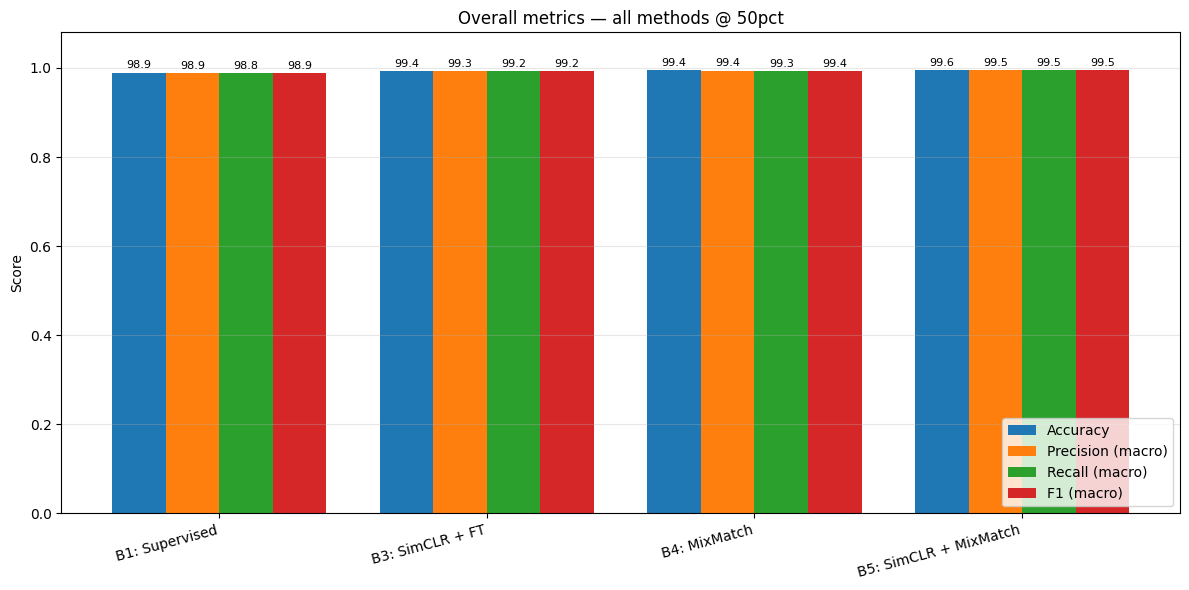

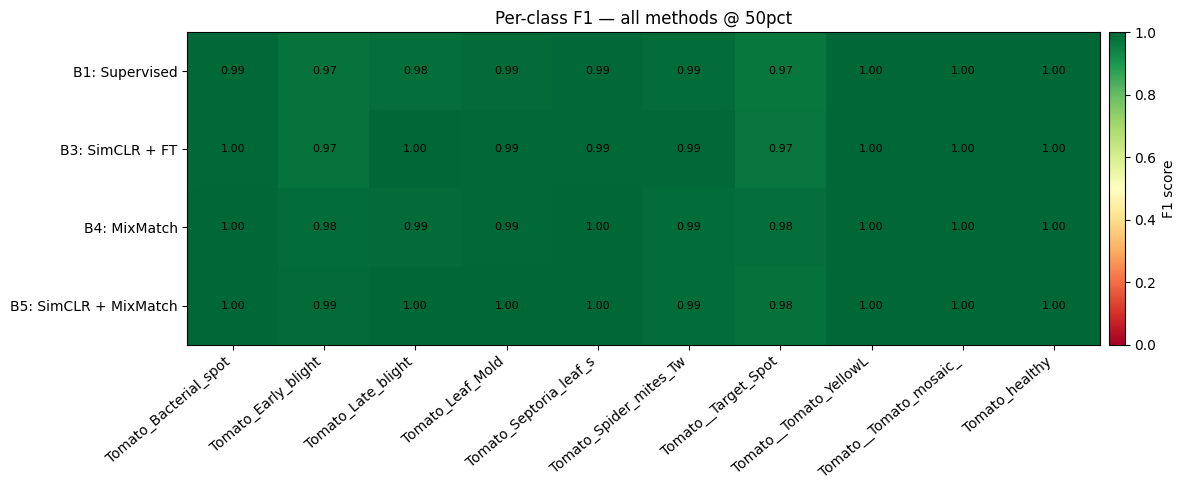

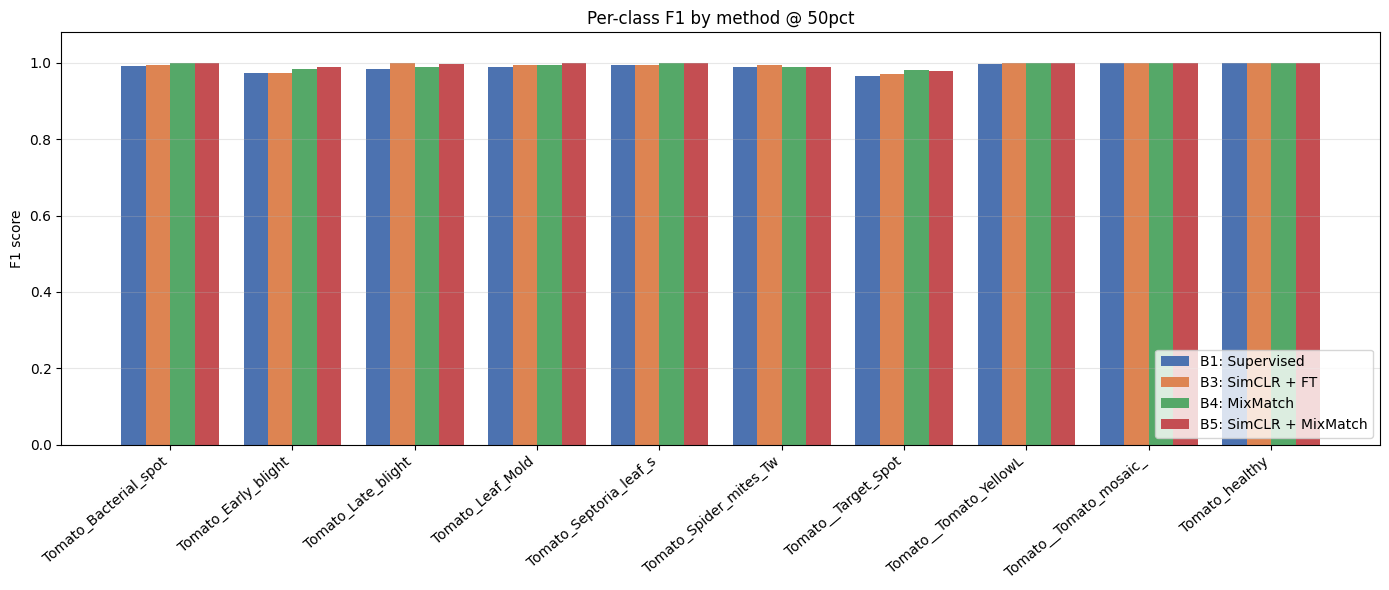


COMPARISON @ 50pct
  Method                         Acc     Prec      Rec       F1    BestVal
  ----------------------------------------------------------------------
  B1: Supervised              98.94%   98.92%   98.82%   98.86%     98.94%
  B3: SimCLR + FT             99.37%   99.29%   99.21%   99.24%     99.37%
  B4: MixMatch                99.44%   99.41%   99.35%   99.38%     99.44%
  B5: SimCLR + MixMatch       99.56%   99.55%   99.51%   99.52%     99.56%

Comparison figures and CSV saved to: /content/drive/MyDrive/Tomato_3regime/RESULTS/50pct/_comparison


In [18]:
# ===== Section 13.5: Compare all 4 models at current pct_tag =====
import json
import numpy as np
import matplotlib.pyplot as plt

METHOD_ORDER = ["B1_supervised", "B3_self_supervised", "B4_semi_supervised", "B5_hybrid"]
METHOD_DISPLAY = {
    "B1_supervised":      "B1: Supervised",
    "B3_self_supervised": "B3: SimCLR + FT",
    "B4_semi_supervised": "B4: MixMatch",
    "B5_hybrid":          "B5: SimCLR + MixMatch",
}

# Load all 4 metrics.json files for the current pct
all_metrics = {}
for method in METHOD_ORDER:
    path = f"{CUR_OUT}/{method}/metrics.json"
    if os.path.exists(path):
        with open(path) as f:
            all_metrics[method] = json.load(f)
    else:
        print(f"WARNING: {path} not found — did the method finish training?")

if len(all_metrics) < 4:
    print(f"Only {len(all_metrics)}/4 methods have metrics. Run remaining methods first.")
else:
    class_names = base_dataset.classes
    n_classes  = len(class_names)
    n_methods  = len(METHOD_ORDER)
    save_dir   = f"{CUR_OUT}/_comparison"
    os.makedirs(save_dir, exist_ok=True)

    # ===== Figure 1: Overall metrics comparison (grouped bars) =====
    metric_keys = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
    metric_labels = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(n_methods)
    w = 0.2
    for j, (mk, ml) in enumerate(zip(metric_keys, metric_labels)):
        vals = [all_metrics[m]["overall"][mk] for m in METHOD_ORDER]
        bars = ax.bar(x + (j - 1.5) * w, vals, w, label=ml)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.005,
                    f"{v*100:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_DISPLAY[m] for m in METHOD_ORDER], rotation=15, ha="right")
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score")
    ax.set_title(f"Overall metrics — all methods @ {pct_tag}")
    ax.legend(loc="lower right")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/overall_metrics_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ===== Figure 2: Per-class F1 heatmap (4 methods × 10 classes) =====
    f1_matrix = np.zeros((n_methods, n_classes))
    for i, m in enumerate(METHOD_ORDER):
        f1_matrix[i] = all_metrics[m]["per_class"]["f1"]

    fig, ax = plt.subplots(figsize=(max(12, n_classes * 1.1), 5))
    im = ax.imshow(f1_matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(n_classes))
    ax.set_xticklabels([c[:22] for c in class_names], rotation=40, ha="right")
    ax.set_yticks(range(n_methods))
    ax.set_yticklabels([METHOD_DISPLAY[m] for m in METHOD_ORDER])
    for i in range(n_methods):
        for j in range(n_classes):
            v = f1_matrix[i, j]
            color = "white" if v < 0.5 else "black"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color=color, fontsize=8)
    ax.set_title(f"Per-class F1 — all methods @ {pct_tag}")
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, label="F1 score")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/per_class_f1_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ===== Figure 3: Per-class metric bars, grouped by class =====
    # For each class, show 4 bars (one per method) of F1 — easiest to read for the paper
    fig, ax = plt.subplots(figsize=(max(14, n_classes * 1.4), 6))
    x = np.arange(n_classes)
    w = 0.2
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
    for i, m in enumerate(METHOD_ORDER):
        vals = all_metrics[m]["per_class"]["f1"]
        ax.bar(x + (i - 1.5) * w, vals, w,
               label=METHOD_DISPLAY[m], color=colors[i])
    ax.set_xticks(x)
    ax.set_xticklabels([c[:22] for c in class_names], rotation=40, ha="right")
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("F1 score")
    ax.set_title(f"Per-class F1 by method @ {pct_tag}")
    ax.legend(loc="lower right")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/per_class_f1_by_method.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ===== Comparison table (text) =====
    print("\n" + "=" * 80)
    print(f"COMPARISON @ {pct_tag}")
    print("=" * 80)
    print(f"  {'Method':<25} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'BestVal':>10}")
    print("  " + "-" * 70)
    rows = []
    for m in METHOD_ORDER:
        o = all_metrics[m]["overall"]
        bv = all_metrics[m].get("best_val_acc", 0)
        rows.append([METHOD_DISPLAY[m],
                     o["accuracy"]*100, o["precision_macro"]*100,
                     o["recall_macro"]*100, o["f1_macro"]*100, bv])
        print(f"  {METHOD_DISPLAY[m]:<25} {o['accuracy']*100:>7.2f}% "
              f"{o['precision_macro']*100:>7.2f}% {o['recall_macro']*100:>7.2f}% "
              f"{o['f1_macro']*100:>7.2f}% {bv:>9.2f}%")

    # Save comparison table as CSV for the paper
    import csv
    with open(f"{save_dir}/comparison_table.csv", "w", newline="") as f:
        w_csv = csv.writer(f)
        w_csv.writerow(["Method", "Accuracy", "Precision_macro", "Recall_macro",
                        "F1_macro", "Best_val_acc"])
        for r in rows:
            w_csv.writerow([r[0]] + [f"{x:.4f}" for x in r[1:]])

    print(f"\nComparison figures and CSV saved to: {save_dir}")